In [1]:
# Imports
import numpy as np
import pandas as pd
import datetime as dt

from typing import Dict, Tuple, Union, Optional, List

import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint, adfuller, kpss

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# data fetching params

# start end time for data download
start = "2020-01-01" # xaut started trading in 2020
end = "2026-04-01"

window = 20 # one trading month - weekday data 5 * 4 = 20
beta_window = 120 # 6 months of trading days - weekday data 5 * 24 = 120 more stable beta estimates
windows = [5, 10, 20, 50, 100]


assets = ['PAXG-USD', 'XAUT-USD', 'GC=F']

In [5]:
# download historical price data - yahoo finace
data = {}
for asset in assets:
    df = yf.download(asset, start=start, end=end)
    df.columns = [col[0] for col in df.columns] # comes as a tuple (field, asset)
    data[asset] = df

# Align data on common dates - only weekdays cos of futures data
data_weekdays = {}
common_dates = set.intersection(*[set(df.index) for df in data.values()])
for asset in assets:
    data_weekdays[asset] = data[asset].loc[data[asset].index.isin(common_dates)].sort_index()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


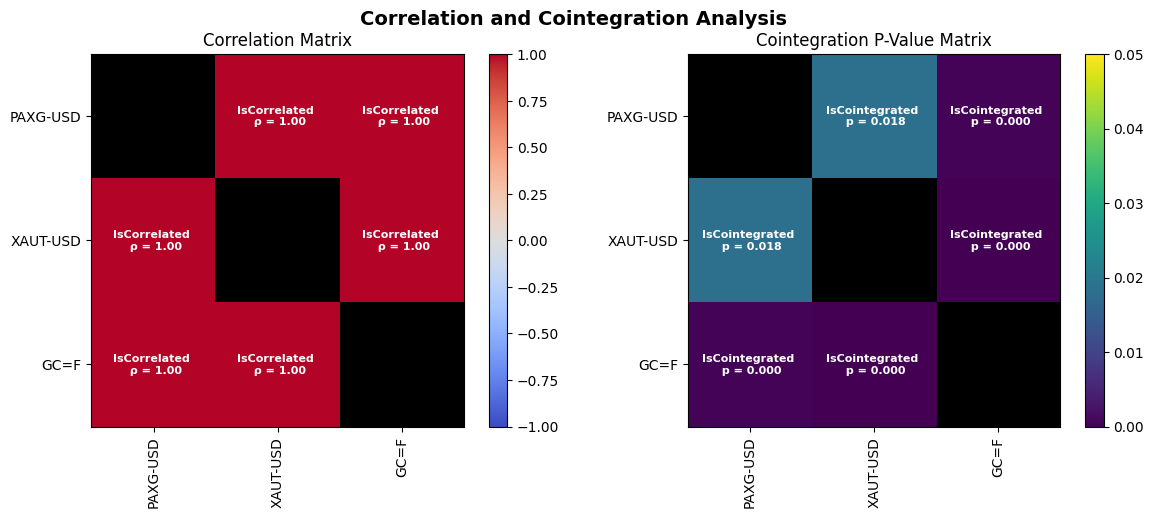

In [17]:
# correlation and cointegration matrices & charts
corr_matrix = np.zeros((len(assets), len(assets)))
coint_matrix = np.zeros((len(assets), len(assets)))

for i in range(len(assets)):
    for j in range(i+1, len(assets)):
        asset_i = data_weekdays[assets[i]]['Close']
        asset_j = data_weekdays[assets[j]]['Close']
        
        # Correlation
        corr_matrix[i, j] = asset_i.corr(asset_j)
        corr_matrix[j, i] = corr_matrix[i, j]


        # Engle-Granger (augmented) cointegration test
        score, pvalue, _ = coint(asset_i, asset_j, trend='c', method='aeg', autolag='aic')
        coint_matrix[i, j] = pvalue
        coint_matrix[j, i] = pvalue


# Plotting the correlation and cointegration matrices
plt.subplots(1, 2, figsize=(12, 5))

# Correlation Matrix with black zeros
plt.subplot(1, 2, 1)
plt.title('Correlation Matrix')
# Create custom colormap where 0 values are black

corr_cmap = plt.cm.coolwarm.copy()
corr_cmap.set_bad('black')  # Set NaN/masked values to black
# Mask zero values to make them black
corr_masked = np.ma.masked_where(np.abs(corr_matrix) < 1e-10, corr_matrix)
im1 = plt.imshow(corr_masked, cmap=corr_cmap, vmin=-1, vmax=1)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and abs(corr_matrix[i, j]) >= 0.7: # check for strong correlation
            plt.text(j, i, f"IsCorrelated \n ρ = {corr_matrix[i, j]:.2f}", ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')

plt.colorbar(im1)  

# Cointegration Matrix with text annotations
coint_cmap = plt.cm.viridis.copy()
coint_cmap.set_bad('black')  # Set values below vmin to white
coint_masked = np.ma.masked_where(coint_matrix == 0, coint_matrix)  # Mask non-significant values
plt.subplot(1, 2, 2)
plt.title('Cointegration P-Value Matrix')
im2 = plt.imshow(coint_masked, cmap=coint_cmap, vmin=0, vmax=0.05)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
# Add text annotations for significant cointegration
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and coint_matrix[i, j] < 0.05:  # Skip diagonal and check significance
            plt.text(j, i, f'IsCointegrated \n p = {coint_matrix[i, j]:.3f}', ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')
        
plt.colorbar(im2)

plt.suptitle('Correlation and Cointegration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
fig = plt.gcf()

# White text styling for saved figure (labels, ticks, titles)
for ax in fig.axes:
    ax.tick_params(axis='both', colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('white')

# Suptitle and any figure-level text
for txt in fig.texts:
    txt.set_color('white')

fig.savefig("corr-coint-matrices.png", dpi=300, bbox_inches="tight", transparent=True)

# use black styling for in-notebook display
for ax in fig.axes:
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    for spine in ax.spines.values():
        spine.set_color('black')

for txt in fig.texts:
    txt.set_color('black')

# reset global defaults for subsequent plots
plt.rcdefaults()
plt.show()




In [ ]:
# Function to compute spread with optional beta adjustment
def compute_spread(data, asset1, asset2, beta=True, debug=True):
    # Get data for the two specific assets
    df1 = data[asset1].copy()
    df2 = data[asset2].copy()
    
    # Find common dates between these two assets only
    common_dates = set(df1.index).intersection(set(df2.index))
    
    # Align both dataframes to common dates
    df1_aligned = df1.loc[df1.index.isin(common_dates)].sort_index()
    df2_aligned = df2.loc[df2.index.isin(common_dates)].sort_index()
    
    if beta:
        model = OLS(df1_aligned['Close'], add_constant(df2_aligned['Close'])).fit()
        beta_est = model.params.iloc[1]
        spread = df1_aligned['Close'] - beta_est * df2_aligned['Close']
        if debug:
            print(f"Estimated Beta for {asset1}-{asset2} : {beta_est:.4f}")
        spread.name = f'{asset1}_{asset2}_spread_beta_adj'
    else:
        spread = df1_aligned['Close'] - df2_aligned['Close']
        spread.name = f'{asset1}_{asset2}_spread'
    return spread

In [ ]:
# def compute_spread(data, asset1, asset2, beta=True, debug=True, static=False):
#     # Function to compute spread with optional rolling beta adjustment
def compute_spread(data, asset1, asset2, beta=True, rolling_window=60, min_periods=20, debug=True):
    """
    Compute spread between two assets with optional rolling beta adjustment
    
    Args:
        data: Dictionary of dataframes with price data
        asset1, asset2: Asset names
        beta: Whether to apply beta adjustment
        rolling_window: Rolling window for beta estimation (default 60 days)
        min_periods: Minimum periods required for beta calculation
        debug: Whether to print debug information
    """
    # Get data for the two specific assets
    df1 = data[asset1].copy()
    df2 = data[asset2].copy()
    
    # Find common dates between these two assets only
    common_dates = set(df1.index).intersection(set(df2.index))
    
    # Align both dataframes to common dates
    df1_aligned = df1.loc[df1.index.isin(common_dates)].sort_index()
    df2_aligned = df2.loc[df2.index.isin(common_dates)].sort_index()
    
    if beta:
        # Calculate rolling beta
        rolling_betas = []
        
        for i in range(len(df1_aligned)):
            if i < min_periods - 1:
                rolling_betas.append(np.nan)
            else:
                # Define the rolling window
                start_idx = max(0, i - rolling_window + 1)
                end_idx = i + 1
                
                # Get the window data
                y_window = df1_aligned['Close'].iloc[start_idx:end_idx]
                x_window = df2_aligned['Close'].iloc[start_idx:end_idx]
                
                # Skip if insufficient data
                if len(y_window) < min_periods:
                    rolling_betas.append(np.nan)
                    continue
                
                try:
                    # OLS regression: y = alpha + beta * x
                    model = OLS(y_window, add_constant(x_window)).fit()
                    beta_est = model.params.iloc[1]
                    rolling_betas.append(beta_est)
                except:
                    rolling_betas.append(np.nan)
        
        # Convert to pandas series
        beta_series = pd.Series(rolling_betas, index=df1_aligned.index)
        
        # Calculate spread using rolling beta: asset1 - beta(t) * asset2
        spread = df1_aligned['Close'] - beta_series * df2_aligned['Close']
        
        if debug:
            valid_betas = beta_series.dropna()
            print(f"Rolling Beta for {asset1}-{asset2} (window={rolling_window})")
            print(f"  Mean: {valid_betas.mean():.4f}")
            print(f"  Std: {valid_betas.std():.4f}")
            print(f"  Min: {valid_betas.min():.4f}")
            print(f"  Max: {valid_betas.max():.4f}")
            print(f"  Valid observations: {len(valid_betas)}/{len(beta_series)}")
        
        spread.name = f'{asset1}_{asset2}_spread_rolling_beta_{rolling_window}d'
    else:
        spread = df1_aligned['Close'] - df2_aligned['Close']
        spread.name = f'{asset1}_{asset2}_spread'
    
    if beta:
        return spread, beta_series
    return spread, pd.Series(1.0, index=spread.index, name='beta')

In [ ]:
# compute spreads

spreads = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD', beta=False)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', beta=False)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', beta=False)[0],
}

spreads_beta = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
}

# remove NaNs from each spread series

print(f"NaN counts before dropping: {[series.isna().sum() for series in spreads.values()]}")
spreads = {name: series.dropna() for name, series in spreads.items()}

print(f"NaN counts before dropping: {[series.isna().sum() for series in spreads_beta.values()]}")
spreads_beta = {name: series.dropna() for name, series in spreads_beta.items()}





# z-scores
rolling_zscore = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads.items()
}

exp_zscore = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads.items()
}

rolling_zscore_beta = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads_beta.items()
}

exp_zscore_beta = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads_beta.items()
}

# add z-score columns directly into the existing spreads dict
for name, series in spreads.items():
    spreads[name] = series.to_frame(name='spread')
    spreads[name]['rolling_zscore'] = rolling_zscore[name]
    spreads[name]['exp_zscore'] = exp_zscore[name]

for name, series in spreads_beta.items():
    spreads_beta[name] = series.to_frame(name='spread')
    spreads_beta[name]['rolling_zscore'] = rolling_zscore_beta[name]
    spreads_beta[name]['exp_zscore'] = exp_zscore_beta[name]



# keep existing variable names used by later cells
paxg_xaut_spread = spreads['PAXG-XAUT']
paxg_xau_spread = spreads['PAXG-XAU']
xaut_xau_spread = spreads['XAUT-XAU']
paxg_xaut_spread_beta = spreads_beta['PAXG-XAUT']
paxg_xau_spread_beta = spreads_beta['PAXG-XAU']
xaut_xau_spread_beta = spreads_beta['XAUT-XAU']


Rolling Beta for PAXG-USD-XAUT-USD (window=120)
  Mean: 0.9973
  Std: 0.0968
  Min: 0.5832
  Max: 1.2865
  Valid observations: 2226/2245
Rolling Beta for PAXG-USD-GC=F (window=120)
  Mean: 0.9900
  Std: 0.0816
  Min: 0.5607
  Max: 1.1745
  Valid observations: 1527/1546
Rolling Beta for XAUT-USD-GC=F (window=120)
  Mean: 0.9836
  Std: 0.0401
  Min: 0.8272
  Max: 1.0736
  Valid observations: 1527/1546
NaN counts before dropping: [np.int64(0), np.int64(0), np.int64(0)]
NaN counts before dropping: [np.int64(19), np.int64(19), np.int64(19)]


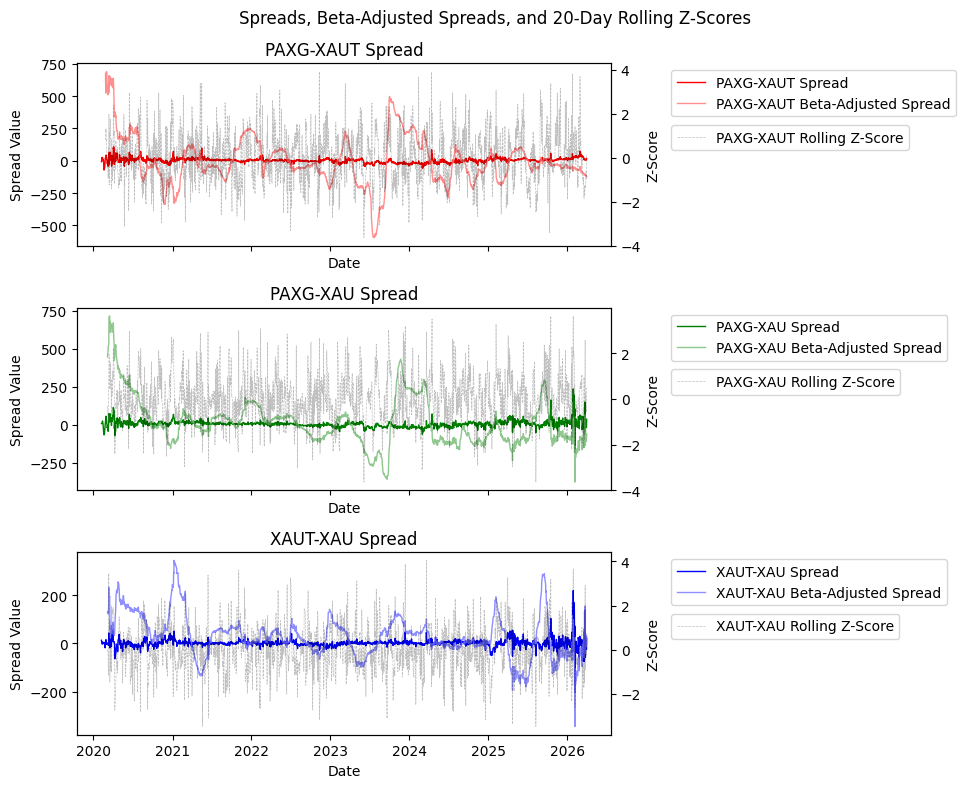

In [ ]:
# Plot of spreads, z-scores, and beta-adjusted spreads
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

colors = ['red', 'green', 'blue']

names = ['PAXG-XAUT', 'PAXG-XAU', 'XAUT-XAU']

for i, name in enumerate(names):
    # Original Spread
    axs[i].plot(spreads[name]['spread'], label=f'{name} Spread', color = colors[i], alpha=1, linewidth=1)
    axs[i].set_title(f'{name} Spread')
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Spread Value')


    
    # Beta-adjusted spread with lighter shade of the same base color
    base = np.array(mcolors.to_rgb(colors[i]))
    lighter_color = tuple(base + (1 - base) * 0.45)  # increase toward white
    axs[i].plot(
        spreads_beta[name]['spread'],
        color=lighter_color,
        label=f'{name} Beta-Adjusted Spread',
        alpha=0.8,
        linewidth=1
    )
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))

    # Z-Scores
    twin = axs[i].twinx()
    twin.plot(spreads[name]['rolling_zscore'], label=f'{name} Rolling Z-Score', color='black', alpha=0.25, linestyle='--', linewidth=0.5)
    twin.legend(loc='upper left', bbox_to_anchor=(1.1, 0.7))
    twin.set_ylabel('Z-Score')

plt.suptitle(f'Spreads, Beta-Adjusted Spreads, and {window}-Day Rolling Z-Scores')
plt.tight_layout()
plt.show()


In [ ]:
# Stationarity Testing - ADF, KPSS

adf_stationarity = {}
kpss_stationarity = {}

for name, series in spreads.items():
    adf_result = adfuller(series['spread'].dropna())
    kpss_result = kpss(series['spread'].dropna(), regression='c', nlags='auto')
    
    adf_stationarity[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }

adf_stationarity_beta = {}
kpss_stationarity_beta = {}

for name, series in spreads_beta.items():
    adf_result = adfuller(series['spread'].dropna())
    kpss_result = kpss(series['spread'].dropna(), regression='c', nlags='auto')
    
    adf_stationarity_beta[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity_beta[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }
    
for name, result in adf_stationarity.items():
    print(f"{name}: ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")
    
for name, result in kpss_stationarity.items():
    print(f"{name}: KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} is likely stationary (Fail to reject null hypothesis of stationarity)")

for name, result in adf_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")

for name, result in kpss_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Fail to reject null hypothesis of stationarity)")

PAXG-XAUT: ADF Statistic = -4.9415, p-value = 0.0000
   Critical Value (1%): -3.4333
   Critical Value (5%): -2.8628
   Critical Value (10%): -2.5675
   => PAXG-XAUT is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-XAU: ADF Statistic = -4.4840, p-value = 0.0002
   Critical Value (1%): -3.4346
   Critical Value (5%): -2.8634
   Critical Value (10%): -2.5678
   => PAXG-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
XAUT-XAU: ADF Statistic = -6.2999, p-value = 0.0000
   Critical Value (1%): -3.4347
   Critical Value (5%): -2.8634
   Critical Value (10%): -2.5678
   => XAUT-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-XAUT: KPSS Statistic = 1.0474, p-value = 0.0100
   Critical Value (10%): 0.3470
   Critical Value (5%): 0.4630
   Critical Value (2.5%): 0.5740
   Critical Value (1%): 0.7390
   => PAXG-XAUT is likely non-stationa

C:\Users\ayode\AppData\Local\Temp\ipykernel_28264\881010247.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series['spread'].dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_28264\881010247.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series['spread'].dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_28264\881010247.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series['spread'].dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_28264\881010247.py:27: 

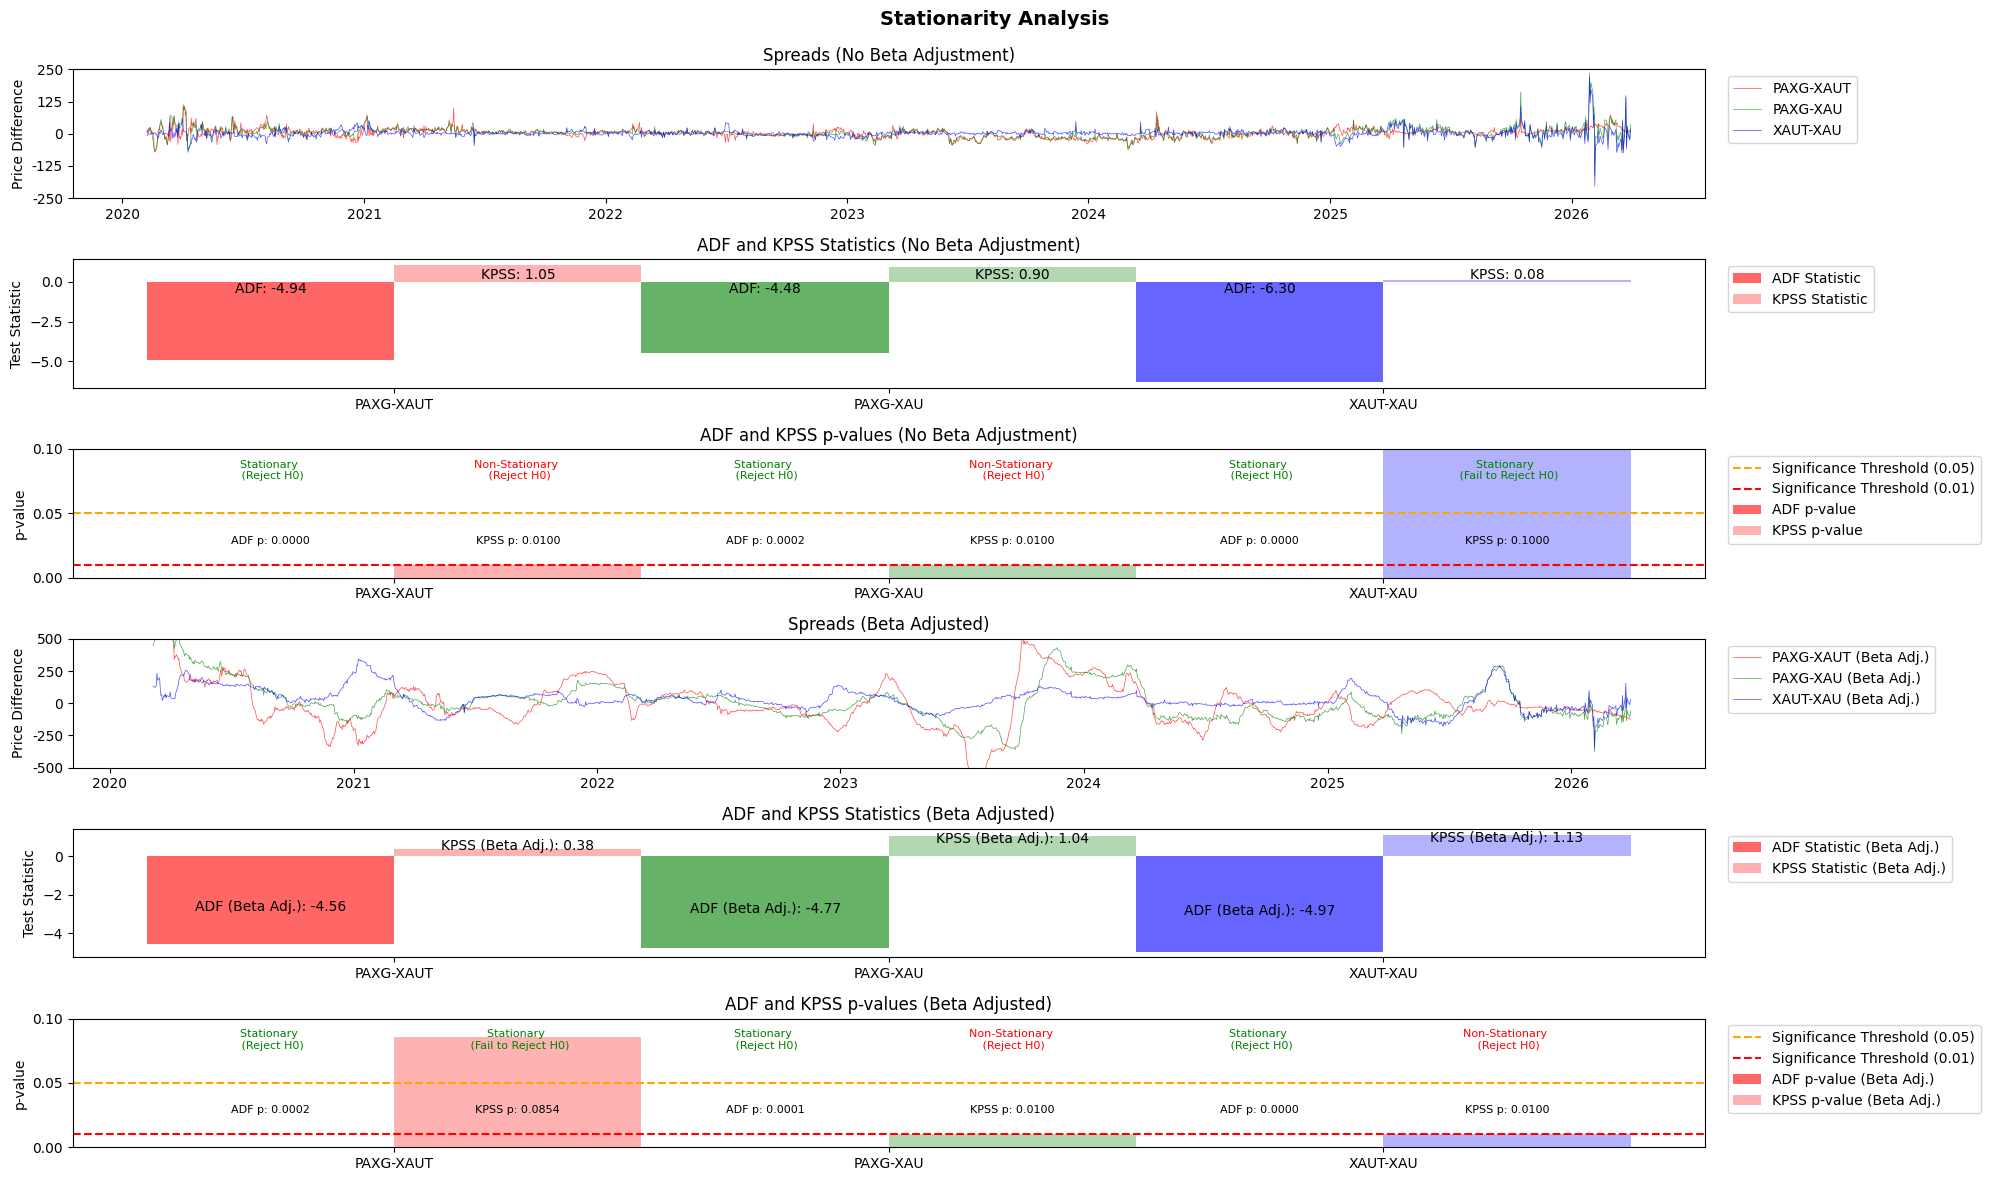

In [ ]:
# Create consistent color scheme for all spreads
colors = ['red', 'green', 'blue']
spread_names = list(spreads.keys())

fig, axs = plt.subplots(6, 1, figsize=(20, 12))

# Plot spreads without beta adjustment
for i, (name, series) in enumerate(spreads.items()):
    axs[0].plot(series['spread'], color=colors[i], label=name, alpha=0.7, linewidth=0.5)


# Plot ADF and KPSS statistics for regular spreads
bar_width = 0.5
x_positions = np.arange(len(spread_names))

# ADF Statistics (No Beta Adjustment)
adf_values = [adf_stationarity[name]['ADF Statistic'] for name in spread_names]
adf_critical_values = [[adf_stationarity[name]['Critical Values'][cv] for cv in ['1%', '5%', '10%']] for name in spread_names]
axs[1].bar(x_positions - bar_width/2, adf_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic')

for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values)):
    axs[1].text(pos, 0, f"ADF: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
    added_labels = set()
    # for i, (pos, crit_vals) in enumerate(zip(x_positions - bar_width/2, adf_critical_values)):
    #     for cv_label, cv_value in zip(['1%', '5%', '10%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '1%' else 'darkturquoise' if cv_label == '5%' else 'paleturquoise'
    #         label = f'ADF Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')# label=label)
    #         added_labels.add(cv_label)

# KPSS Statistics (No Beta Adjustment)
kpss_values = [kpss_stationarity[name]['KPSS Statistic'] for name in spread_names]
kpss_critical_values = [[kpss_stationarity[name]['Critical Values'][cv] for cv in ['10%', '5%', '2.5%', '1%']] for name in spread_names]
axs[1].bar(x_positions + bar_width/2, kpss_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic')

for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values)):
    axs[1].text(pos, 0, f"KPSS: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')

    # for i, (pos, crit_vals) in enumerate(zip(x_positions + bar_width/2, kpss_critical_values)):
    #     for cv_label, cv_value in zip(['10%', '5%', '2.5%', '1%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '10%' else 'darkturquoise' if cv_label == '5%' else 'cadetblue' if cv_label == '2.5%' else 'paleturquoise'
    #         label = f'KPSS Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')#, label=label)
    #         added_labels.add(cv_label)


# p-values for ADF and KPSS tests
axs[2].bar(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value')
axs[2].bar(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value')
axs[2].axhline(0.05, color='orange', linestyle='--', label='Significance Threshold (0.05)')
axs[2].axhline(0.01, color='red', linestyle='--', label='Significance Threshold (0.01)')
# ADF p-value annotations (p < 0.05 = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < 0.05 else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < 0.05 else 'red')
# KPSS p-value annotations (p < 0.05 = Non-Stationary) 
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < 0.05 else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < 0.05 else 'green')



# Plot spreads with beta adjustment
for i, (name, series) in enumerate(spreads_beta.items()):
    axs[3].plot(series['spread'], color=colors[i], label=name + ' (Beta Adj.)', linewidth=0.5, alpha=0.7)

# ADF Statistics (Beta Adjustment)
adf_values_beta = [adf_stationarity_beta[name]['ADF Statistic'] for name in spread_names]
axs[4].bar(x_positions - bar_width/2, adf_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values_beta)):
    axs[4].text(pos, val/2, f"ADF (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
# KPSS Statistics (Beta Adjustment)
kpss_values_beta = [kpss_stationarity_beta[name]['KPSS Statistic'] for name in spread_names]
axs[4].bar(x_positions + bar_width/2, kpss_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values_beta)):
    axs[4].text(pos, val/2, f"KPSS (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')


# p-values for ADF and KPSS tests with Beta Adjustment
axs[5].bar(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value (Beta Adj.)')
axs[5].bar(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names],
              width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value (Beta Adj.)')
axs[5].axhline(0.05, color='orange', linestyle='--', label='Significance Threshold (0.05)')
axs[5].axhline(0.01, color='red', linestyle='--', label='Significance Threshold (0.01)')
# ADF p-value annotations (p < 0.05 = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < 0.05 else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < 0.05 else 'red')
# KPSS p-value annotations (p < 0.05 = Non-Stationary)
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < 0.05 else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < 0.05 else 'green')

# Set x-axis labels for bar charts
for ax in [axs[1], axs[2], axs[4], axs[5]]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(spread_names)

# Set titles and labels
axs[0].set_title('Spreads (No Beta Adjustment)')
axs[0].set_ylabel('Price Difference', position=(0, 0.5))
axs[0].set_ylim(-250, 250)
yticks = np.arange(-250, 300, 125)
axs[0].set_yticks(yticks)
axs[0].set_yticklabels([f"{y:.0f}" for y in yticks])


axs[1].set_title('ADF and KPSS Statistics (No Beta Adjustment)')
axs[1].set_ylabel('Test Statistic')

axs[2].set_title('ADF and KPSS p-values (No Beta Adjustment)')
axs[2].set_ylabel('p-value')

axs[3].set_title('Spreads (Beta Adjusted)')
axs[3].set_ylabel('Price Difference')
axs[3].set_ylim(-500, 500)
yticks = np.arange(-500, 600, 250)
axs[3].set_yticks(yticks)
axs[3].set_yticklabels([f"{y:.0f}" for y in yticks])

axs[4].set_title('ADF and KPSS Statistics (Beta Adjusted)')
axs[4].set_ylabel('Test Statistic')

axs[5].set_title('ADF and KPSS p-values (Beta Adjusted)')
axs[5].set_ylabel('p-value')

for i in 2,5:
    axs[i].set_ylim(0, 0.1)
    yticks = np.arange(0, 0.15, 0.05)
    axs[i].set_yticks(yticks)
    axs[i].set_yticklabels([f"{y:.2f}" for y in yticks])

# Add legends
axs[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[3].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[4].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[5].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Stationarity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave 1% space at top for suptitle
plt.show()

# todo** change bar chart legend to be neutral blaclk grey

In [ ]:
# Bid-Ask Spread Estimation - Corwin Schultz (2012)
'''
S = 2 * (exp(alpha) - 1) / (1 + exp(alpha))
Where:
alpha = (sqrt(2 * beta) - sqrt(beta)) / k - sqrt(gamma / k)
beta = (log(H_2d / L_2d))^2
gamma = (log(H / L))^2
k = 3 - 2 * sqrt(2) ≈ 0.1715728752538099

S is the estimated bid-ask spread
H is the high price
L is the low price
'''

def cs_spread_estimator(df: pd.DataFrame, k: float = 3 - 2 * np.sqrt(2), abs: bool = False, bps: bool = False, pips: bool = False) -> pd.Series:

    df = df[['High', 'Low']].dropna()
    df = df[(df['High'] > 0) & (df['Low'] > 0)]

    high = df['High']
    low = df['Low']

    # 2-day high/low
    high_2d = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    low_2d = pd.concat([low, low.shift(1)], axis=1).min(axis=1)

    beta = (np.log(high_2d / low_2d))**2
    gamma = (np.log(high / low))**2

    # align
    valid = beta.notna() & gamma.notna()
    beta = beta[valid]
    gamma = gamma[valid]

    alpha = (
        (np.sqrt(2 * beta) - np.sqrt(beta)) / k
        - np.sqrt(gamma / k)
    )

    alpha = np.maximum(alpha, 0)

    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))

    # conversions
    if abs:
        avg = (high + low) / 2
        spread = spread * avg

    if bps:
        spread = spread * 10000

    if pips:
        avg = ((high + low) / 2).loc[spread.index]
        spread = (spread * avg) / 0.01
    # else return as a percentage of the mid price
    # lag to avoid lookahead bias
    return spread.shift(1).dropna()

In [ ]:
# Naive Slippage Modelling
'''
Total slippage is modelled as a sum of contributions from order volume, asset price volatility, bid-ask spread, and a minimum slippage component which accounts for market maker comp and other costs
ST = Sbase + Svolume + Svolatility + Sspread

Where:
Sbase = P * (m/10000)
Svolume = P * fV * (Q/Vadv)
Svolatility = P * σ * fV
Sspread = S * fS

P = asset price
m = minimum slippage in bps (e.g. 1 bps = 0.01%)
fV = volume impact factor (e.g. 0.1)
Q = order size
Vadv = average daily volume
σ = asset price volatility (e.g. std dev of returns)
fS = spread factor (e.g. 0.5 to reflect that you typically get half the spread as slippage when crossing the spread)
S = bid-ask spread (can be estimated using Abdi Ranaldo model or observed bid-ask spread from data)
'''

class SlippageModel:
    def __init__(
        self,
        volatility_window: int = 20,
        volume_impact_factor: float = 0.1,
        spread_factor: float = 0.5,
        min_slippage_bps: float = 1.0
    ):
        self.volatility_window = volatility_window
        self.volume_impact_factor = volume_impact_factor
        self.spread_factor = spread_factor
        self.min_slippage_bps = min_slippage_bps

    # function to estimate slippage based on the model
    def estimate_slippage(
        self,
        price: float,
        order_size: float,
        avg_daily_volume: float,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
    ) -> float:
        # Base slippage on minimum bps
        base_slippage = price * (self.min_slippage_bps / 10000)

        # Volume impact component
        volume_ratio = order_size / avg_daily_volume
        volume_impact = price * self.volume_impact_factor * volume_ratio

        # Volatility component (if provided)
        volatility_impact = 0
        if volatility is not None:
            volatility_impact = price * volatility * self.volume_impact_factor

        # Spread component
        spread_impact = 0
        if bid_ask_spread is not None:
            spread_impact = bid_ask_spread * self.spread_factor
        else:
            # Estimate spread as 0.1% of price if not provided
            spread_impact = price * 0.001 * self.spread_factor

        # Combine all components
        total_slippage = base_slippage + volume_impact + volatility_impact + spread_impact

        return total_slippage

    def calculate_volatility(self, prices: pd.Series) -> float:
        returns = prices.pct_change().dropna()
        volatility = returns.rolling(window=self.volatility_window).std()
        return volatility.iloc[-1]

    def estimate_trade_price(
        self,
        current_price: float,
        order_size: float,
        avg_daily_volume: float,
        is_buy: bool,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
    ) -> float:
        slippage = self.estimate_slippage(
            current_price,
            order_size,
            avg_daily_volume,
            volatility,
            bid_ask_spread
        )

        # Add slippage for buys, subtract for sells
        execution_price = current_price + (slippage if is_buy else -slippage)
        return execution_price

In [ ]:
target = 30 # target spread in pips
spread_cs = cs_spread_estimator(data_weekdays['PAXG-USD'], pips=True) #, optimal_k_values['PAXG-USD']['10'])
spread_scaled = (spread_cs / spread_cs.mean()) # scaled in stead of normalized - avoid negatives
spread = spread_scaled * target

In [ ]:
# Naive Slippage Model Test
model = SlippageModel()
pos = np.random.randint(2)  # Randomly choose buy (1) or sell (0)
date = np.random.choice(data_weekdays[assets[0]].index)  # Random date from data
asset = "PAXG-USD" #np.random.choice(assets)  # Random asset
price = data_weekdays[asset].loc[date, 'Close']
order_size = int(np.round(np.random.uniform(1, 100) / 10) * 10)
order_size = max(order_size, 10)  # prevent 0 when random value is very small
avg_daily_volume = 216_240_000  # avg for paxg in 2025
volatility = model.calculate_volatility(data_weekdays[asset]['Close'].loc[:date])
bid_ask_spread = spread.loc[pd.Timestamp(date)]
estimated_slippage = model.estimate_slippage(price, order_size, avg_daily_volume)#, volatility, bid_ask_spread)
estimated_price = model.estimate_trade_price(price, order_size, avg_daily_volume, is_buy=bool(pos))#, volatility=volatility, bid_ask_spread=bid_ask_spread)
print(f"Trade Type: {'Buy' if pos == 1 else 'Sell'}")
print(f"Asset: {asset}")
print(f"Date: {pd.Timestamp(date).strftime('%Y-%m-%d')}")
print(f"Order Size: {order_size} ounces")
print(f"Current Price: ${price:.2f}")
print(f"Execution Price: ${estimated_price:.2f}")
print(f"Notional Value: ${price * order_size:,.2f}")
print(f"Spread (pips): {(bid_ask_spread):.2f} pips")
spread_dollars = abs(bid_ask_spread) * 0.01  # 1 pip = $0.01
print(f"Spread (Price): ${spread_dollars:.4f}")
print(f"Estimated Slippage: ${estimated_slippage:.4f}")
print(f"Estimated Slippage (bps): {estimated_slippage / price * 10000:.2f} bps")
print(f"Estimated Slippage (pips): {estimated_slippage / 0.01:.2f} pips")
print(f"Estimated Broker Fee (Taker): ${price * order_size * 0.0001:.2f} (0.01%)")
print(f"Estimated Total Cost (Price Impact + Broker Fee): ${estimated_price * order_size * 0.0001 + abs(estimated_price - price) * order_size:.2f}")

Trade Type: Buy
Asset: PAXG-USD
Date: 2025-02-25
Order Size: 90 ounces
Current Price: $2936.79
Execution Price: $2938.55
Notional Value: $264,311.02
Spread (pips): 25.64 pips
Spread (Price): $0.2564
Estimated Slippage: $1.7622
Estimated Slippage (bps): 6.00 bps
Estimated Slippage (pips): 176.22 pips
Estimated Broker Fee (Taker): $26.43 (0.01%)
Estimated Total Cost (Price Impact + Broker Fee): $185.04


In [ ]:
start = '2025-01-01'
end = dt.datetime.today().strftime('%Y-%m-%d')
df = data_weekdays['PAXG-USD'].loc[start:end].copy()
df.head(5)

,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,2653.018066,2653.018066,2623.680420,2623.680420,16231294
2025-01-03,2646.816406,2659.088623,2645.624512,2652.659668,17550024
2025-01-06,2656.013184,2656.562500,2639.582520,2645.312744,15780697
2025-01-07,2650.416504,2667.415039,2644.606201,2655.754883,19468966
2025-01-08,2665.394287,2674.052246,2646.330078,2650.416504,21640845


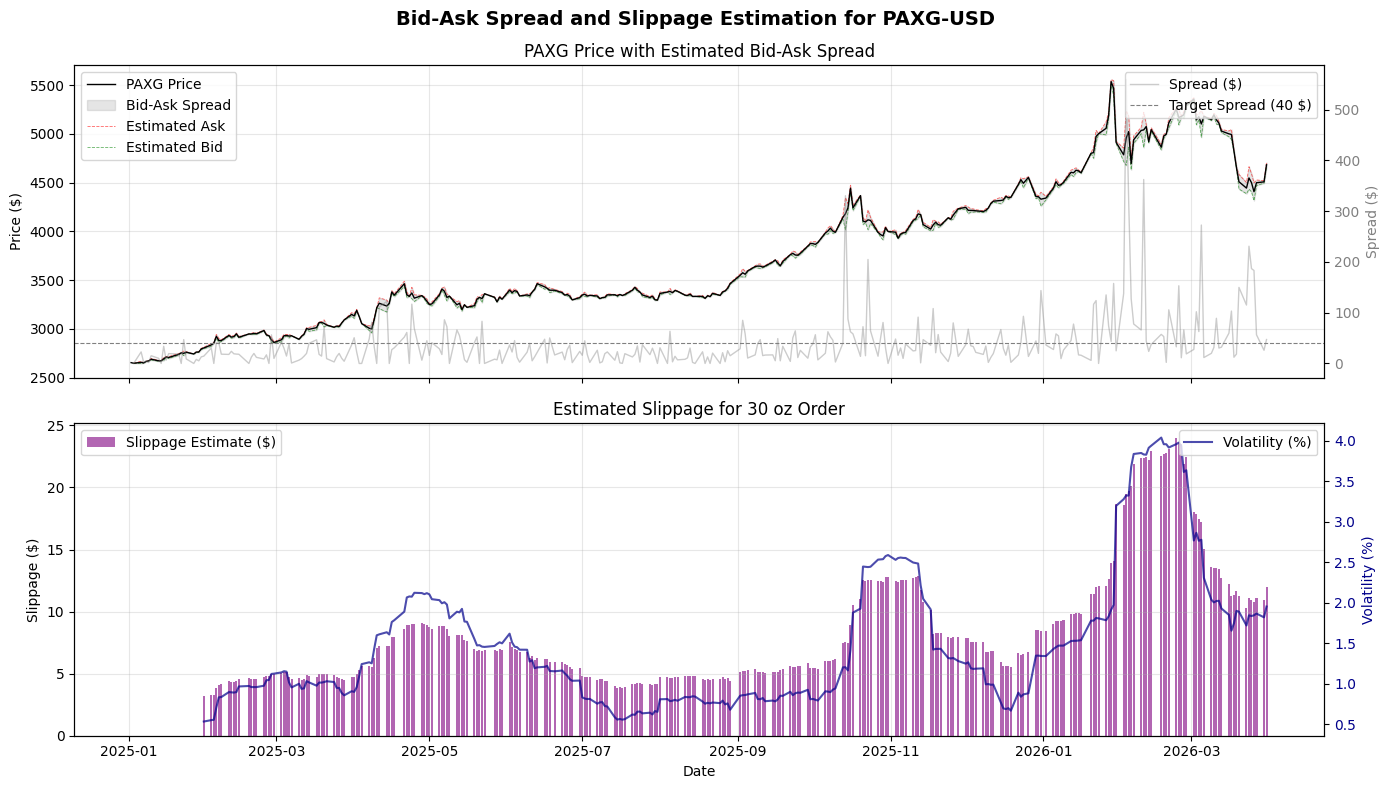

In [ ]:
# Bid Ask Spread & Slippage Sanity Plots
start = '2025-01-01'
end = dt.datetime.today().strftime('%Y-%m-%d')
df = data_weekdays['PAXG-USD'].loc[start:end].copy()

# params
avg_daily_volume = 216_240_000  # avg for paxg in 2025
order_size = 30  # oz
volatility_factors = []

spread_target = 40 # midpoint between 30 tokenised and 50 futures spreads
spread_pips = cs_spread_estimator(df, pips=True).reindex(df.index).ffill()
spread_abs = cs_spread_estimator(df, abs=True).reindex(df.index).ffill()
spread_pips_scaled = (spread_pips / spread_pips.mean()) * spread_target
spread_abs_scaled = (spread_abs / spread_abs.mean()) * (spread_target) # convert pips target to dollars for abs spread





df['Volatility'] = df['Close'].pct_change().rolling(window=20).std()
df['Spread (pips)'] = spread_pips_scaled
df['Spread ($)'] = spread_abs_scaled

df['Slippage Estimate ($)'] = df.apply(
    lambda row: model.estimate_slippage(
        price=row['Close'],
        order_size=order_size,
        avg_daily_volume=avg_daily_volume,
        volatility=row['Volatility'],
        #bid_ask_spread=row['Spread ($)']
    ) if pd.notna(row['Volatility']) and pd.notna(row['Spread ($)']) else np.nan,
    axis=1
)
# Plot asset price with bid/ask spreads and slippage estimates
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Price with Bid-Ask Spread
axs[0].plot(df.index, df['Close'], label='PAXG Price', color='black', linewidth=1, zorder=3)
axs[0].fill_between(df.index, 
                     df['Close'] - df['Spread ($)'] / 2, 
                     df['Close'] + df['Spread ($)'] / 2, 
                     alpha=0.2, color='gray', label='Bid-Ask Spread')
axs[0].plot(df.index, df['Close'] + df['Spread ($)'] / 2, label='Estimated Ask', color='red', linestyle='--', linewidth=0.6, alpha=0.6, zorder=2)
axs[0].plot(df.index, df['Close'] - df['Spread ($)'] / 2, label='Estimated Bid', color='green', linestyle='--', linewidth=0.6, alpha=0.6, zorder=2)
axs[0].set_title('PAXG Price with Estimated Bid-Ask Spread')
axs[0].set_ylabel('Price ($)')
axs[0].legend(loc='upper left')
axs[0].grid(True, alpha=0.3)

# Add spread (pips) on secondary y-axis
twin_ax = axs[0].twinx()
twin_ax.plot(df.index, df['Spread ($)'], label='Spread ($)', color='grey', alpha=0.4, linewidth=1)
twin_ax.axhline(spread_target, color='grey', linestyle='--', linewidth=0.8, label=f'Target Spread ({spread_target} $)')
twin_ax.set_ylabel('Spread ($)', color='grey')
twin_ax.tick_params(axis='y', labelcolor='grey')
twin_ax.legend(loc='upper right')

# Plot 2: Slippage Estimate and Volatility
axs[1].bar(df.index, df['Slippage Estimate ($)'], alpha=0.6, color='purple', label='Slippage Estimate ($)')
axs[1].set_title('Estimated Slippage for 30 oz Order')
axs[1].set_ylabel('Slippage ($)')
axs[1].set_xlabel('Date')
axs[1].legend(loc='upper left')
axs[1].grid(True, alpha=0.3)

# Add volatility on secondary y-axis
twin_ax2 = axs[1].twinx()
twin_ax2.plot(df.index, df['Volatility'] * 100, label='Volatility (%)', color='darkblue', linewidth=1.5, alpha=0.7)
twin_ax2.set_ylabel('Volatility (%)', color='darkblue')
twin_ax2.tick_params(axis='y', labelcolor='darkblue')
twin_ax2.legend(loc='upper right')

plt.suptitle('Bid-Ask Spread and Slippage Estimation for PAXG-USD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Signal Generation Parameters
window = 20
entry_threshold = 2
exit_threshold = 0
beta_adj = False
asset_A = 'XAUT-USD' # xaut usd
asset_B = 'GC=F' # gold futures



# Time Considerations
test_start = None #'2026-01-01'
test_end = None #dt.datetime.now().strftime('%Y-%m-%d')

# Slippage & Spread Parameters
slippage_const = 0.0005 # 5 bps slippage constant
ba_spread_target = 30 # target spread in pips

In [ ]:
# Data Prep
spread, beta = compute_spread(data_weekdays, asset_A, asset_B, beta=beta_adj, debug=False)
zscore = (spread - spread.rolling(window=window).mean()) / spread.rolling(window=window).std()

df = pd.DataFrame({
    asset_A: data_weekdays[asset_A]['Close'],
    asset_B: data_weekdays[asset_B]['Close'],
    'Spread': spread,
    'Z-Score': zscore})

if test_start is not None and test_end is not None:
    df = df.loc[test_start:test_end]

In [ ]:
# Signal Generation
# Long Entry: Z-Score < -threshold
# Long Exit: if in a position, and position is long, when z score normalizes (crosses exit_threshold), sell and exit position
# Short Entry: Z-Score > threshold
# Short Exit: if in a position, and position is short, when z score normalizes (crosses exit_threshold), buy and exit position

df['Position'] = 0  # 1 for long, -1 for short, 0 for flat
for i in range(1, len(df)):
    if df['Position'].iloc[i-1] == 0:  # No current position
        if df['Z-Score'].iloc[i] < -entry_threshold:
            df.at[df.index[i], 'Position'] = 1  # Enter long
        elif df['Z-Score'].iloc[i] > entry_threshold:
            df.at[df.index[i], 'Position'] = -1  # Enter short
    elif df['Position'].iloc[i-1] == 1:  # Currently long
        if df['Z-Score'].iloc[i] >= exit_threshold:
            df.at[df.index[i], 'Position'] = 0  # Exit long
        else:
            df.at[df.index[i], 'Position'] = 1  # Stay long
    elif df['Position'].iloc[i-1] == -1:  # Currently short
        if df['Z-Score'].iloc[i] <= exit_threshold:
            df.at[df.index[i], 'Position'] = 0  # Exit short
        else:
            df.at[df.index[i], 'Position'] = -1  # Stay short

# Performance Evaluation
# calculate returns
df['Asset_A_Return'] = df[asset_A].pct_change()
df['Asset_B_Return'] = df[asset_B].pct_change()

# align beta series to df index
df['Beta'] = beta.reindex(df.index).ffill()

# spread return, then apply previous day's position to avoid lookahead bias
spread_return = df['Asset_A_Return'] - df['Beta'] * df['Asset_B_Return']
df['Strategy_Return'] = df['Position'].shift(1).fillna(0) * spread_return

# apply fees to strategy returns
df['Strategy_Return'] = df['Strategy_Return'] - slippage_const * df['Position'].diff().abs().fillna(0)

# optional cleanup for first row
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)

In [ ]:
# * todo add bid ask spread and vol to slippage model.make sure slippage is in same space as when its used in calculation. also trade volume for futures has standard sizing. lot size vs fractional token... add equity curve to dashboard.
# add performance metrics comparisons, native assets vs strategy in table under last bottomright subplot
# equity curve in bottom left.

In [ ]:
# 2 Leg PNL Calculations with individual trade tracking

# Initialize slippage model
slippage_model = SlippageModel(min_slippage_bps=1.0)  # 1 bps minimum

# Trade tracking lists
trades = []
current_trade = None

# Get position change points
position_changes = df['Position'].diff().fillna(0)
entry_points = position_changes != 0
exit_points = (df['Position'] == 0) & (df['Position'].shift(1) != 0)

# Process each trade
for i in range(1, len(df)):
    current_pos = df['Position'].iloc[i]
    prev_pos = df['Position'].iloc[i-1]
    
    # Trade entry
    if prev_pos == 0 and current_pos != 0:
        current_trade = {
            'entry_date': df.index[i],
            'entry_zscore': df['Z-Score'].iloc[i],
            'direction': 'long' if current_pos == 1 else 'short',
            'position_size': 1.0,  # Normalize to 1 unit
        }
        
        # Entry prices
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df['Beta'].iloc[i]
        
        # Calculate slippage for entry
        # Asset A slippage (assume average daily volume)
        vol_a = 50_000_000  # Estimate for XAUT
        vol_b = 500_000_000  # Estimate for GC futures
        
        if current_pos == 1:  # Long spread: Buy A, Sell B
            slip_a = slippage_model.estimate_slippage(asset_a_price, 1000, vol_a)
            slip_b = slippage_model.estimate_slippage(asset_b_price, 1000 * beta_value, vol_b)
            current_trade['entry_price_a'] = asset_a_price + slip_a
            current_trade['entry_price_b'] = asset_b_price - slip_b  # Sell, so get worse price
        else:  # Short spread: Sell A, Buy B
            slip_a = slippage_model.estimate_slippage(asset_a_price, 1000, vol_a)
            slip_b = slippage_model.estimate_slippage(asset_b_price, 1000 * beta_value, vol_b)
            current_trade['entry_price_a'] = asset_a_price - slip_a  # Sell, so get worse price
            current_trade['entry_price_b'] = asset_b_price + slip_b
            
        current_trade['entry_slippage_a'] = slip_a
        current_trade['entry_slippage_b'] = slip_b
        current_trade['beta'] = beta_value
    
    # Trade exit
    elif prev_pos != 0 and current_pos == 0 and current_trade is not None:
        # Exit prices
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df['Beta'].iloc[i]
        
        # Calculate slippage for exit (opposite direction from entry)
        if current_trade['direction'] == 'long':  # Exit long: Sell A, Buy B
            slip_a = slippage_model.estimate_slippage(asset_a_price, 1000, vol_a)
            slip_b = slippage_model.estimate_slippage(asset_b_price, 1000 * beta_value, vol_b)
            current_trade['exit_price_a'] = asset_a_price - slip_a  # Sell
            current_trade['exit_price_b'] = asset_b_price + slip_b  # Buy
        else:  # Exit short: Buy A, Sell B
            slip_a = slippage_model.estimate_slippage(asset_a_price, 1000, vol_a)/100   
            slip_b = slippage_model.estimate_slippage(asset_b_price, 1000 * beta_value, vol_b)
            current_trade['exit_price_a'] = asset_a_price + slip_a  # Buy
            current_trade['exit_price_b'] = asset_b_price - slip_b  # Sell
            
        current_trade['exit_date'] = df.index[i]
        current_trade['exit_zscore'] = df['Z-Score'].iloc[i]
        current_trade['exit_slippage_a'] = slip_a
        current_trade['exit_slippage_b'] = slip_b
        
        # Calculate holding period
        current_trade['holding_period'] = (current_trade['exit_date'] - current_trade['entry_date']).days
        
        # Calculate PnL for each leg
        if current_trade['direction'] == 'long':
            # Long spread: profit when A outperforms B
            pnl_a = current_trade['exit_price_a'] - current_trade['entry_price_a']
            pnl_b = (current_trade['entry_price_b'] - current_trade['exit_price_b']) * current_trade['beta']
        else:
            # Short spread: profit when B outperforms A  
            pnl_a = current_trade['entry_price_a'] - current_trade['exit_price_a']
            pnl_b = (current_trade['exit_price_b'] - current_trade['entry_price_b']) * current_trade['beta']
        
        current_trade['pnl_a'] = pnl_a
        current_trade['pnl_b'] = pnl_b
        current_trade['net_pnl'] = pnl_a + pnl_b
        
        # Calculate total costs (slippage + fees)
        total_slippage = (current_trade['entry_slippage_a'] + current_trade['exit_slippage_a'] + 
                         current_trade['entry_slippage_b'] + current_trade['exit_slippage_b'])
        current_trade['total_slippage'] = total_slippage
        
        # Add fee structure (assume 0.1% per side) binance retail - in reality dependent on maker/taker and volume tiers
        fee_rate = 0.0001 #0
        total_fees = fee_rate * (current_trade['entry_price_a'] + current_trade['entry_price_b'] * current_trade['beta'] +
                                current_trade['exit_price_a'] + current_trade['exit_price_b'] * current_trade['beta'])
        current_trade['total_fees'] = total_fees
        current_trade['total_costs'] = total_slippage + total_fees
        
        # Net PnL after costs
        current_trade['net_pnl_after_costs'] = current_trade['net_pnl'] - current_trade['total_costs']
        
        # Return calculations
        entry_value = current_trade['entry_price_a'] + current_trade['entry_price_b'] * current_trade['beta']
        current_trade['return_pct'] = current_trade['net_pnl_after_costs'] / entry_value * 100
        
        trades.append(current_trade.copy())
        current_trade = None

# Convert to DataFrame
trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    print(f"Total Trades: {len(trades_df)}")
    print(f"Winning Trades: {len(trades_df[trades_df['net_pnl_after_costs'] > 0])}")
    print(f"Losing Trades: {len(trades_df[trades_df['net_pnl_after_costs'] < 0])}")
    print(f"Win Rate: {len(trades_df[trades_df['net_pnl_after_costs'] > 0]) / len(trades_df) * 100:.1f}%")
    print(f"Average Return per Trade: {trades_df['return_pct'].mean():.4f}%")
    print(f"Best Trade: {trades_df['return_pct'].max():.4f}%")
    print(f"Worst Trade: {trades_df['return_pct'].min():.4f}%")
    print(f"Average Holding Period: {trades_df['holding_period'].mean():.1f} days")
    print(f"Total Slippage per Trade (avg): ${trades_df['total_slippage'].mean():.4f}")
    print(f"Total Fees per Trade (avg): ${trades_df['total_fees'].mean():.4f}")
else:
    print("No trades executed")

Total Trades: 79
Winning Trades: 69
Losing Trades: 10
Win Rate: 87.3%
Average Return per Trade: 0.4095%
Best Trade: 2.1290%
Worst Trade: -0.2476%
Average Holding Period: 5.2 days
Total Slippage per Trade (avg): $5.0338
Total Fees per Trade (avg): $0.9482


In [ ]:
# 2 Leg PNL Calculations with individual trade tracking
# Replacement cell:
# - Buy at ask, sell at bid using Corwin-Schultz full spread / 2
# - Adds naive market-impact slippage on top of bid/ask execution
# - Sizes token leg from whole futures contracts
# - Keeps original output columns used by plotting:
#   trades_df, entry_date, exit_date, direction, entry_zscore, exit_zscore,
#   entry_price_a/b, exit_price_a/b, entry_slippage_a/b, exit_slippage_a/b,
#   beta, holding_period, pnl_a, pnl_b, net_pnl, total_slippage,
#   total_fees, total_costs, net_pnl_after_costs, return_pct

import numpy as np
import pandas as pd

# -----------------------------
# Config
# -----------------------------

slippage_model = SlippageModel(min_slippage_bps=1.0)  # 1 bps minimum

# Use MGC-style sizing by default.
# MGC = 10 oz. GC = 100 oz.
futures_contract_size_oz = 10
target_futures_contracts = 3

# Token fee: Binance retail taker-ish assumption.
# This is applied only to token notional, not futures notional.
token_fee_rate = 0.001

# Futures all-in fee estimate per contract per side.
# Tune this to your broker/exchange reality.
futures_fee_per_contract = 1.50

# Fallback daily dollar volume assumptions if real volume cols are missing.
fallback_token_dollar_volume = 50_000_000
fallback_futures_dollar_volume = 500_000_000

# Fallback full bid/ask spread in bps if CS spread is missing.
fallback_token_spread_bps = 1.0
fallback_futures_spread_bps = 1.0


# -----------------------------
# Corwin-Schultz spread series
# -----------------------------
# Assumes cs_spread_estimator() already exists and data_weekdays[asset] has High/Low columns.
# Returns full bid/ask spread in absolute dollars, lagged by 1 day inside the function.

try:
    spread_a_series = cs_spread_estimator(
        data_weekdays[asset_A],
        abs=True,
        bps=False,
        pips=False
    ).reindex(df.index).ffill()
except Exception:
    spread_a_series = pd.Series(index=df.index, data=np.nan)

try:
    spread_b_series = cs_spread_estimator(
        data_weekdays[asset_B],
        abs=True,
        bps=False,
        pips=False
    ).reindex(df.index).ffill()
except Exception:
    spread_b_series = pd.Series(index=df.index, data=np.nan)


# -----------------------------
# Helpers
# -----------------------------

def get_cs_spread_dollars(date, spread_series, mid_price, fallback_bps):
    """
    Full bid/ask spread in dollars.
    Corwin-Schultz spread is expected to be absolute dollar spread.
    """
    spread_val = np.nan

    if date in spread_series.index:
        spread_val = spread_series.loc[date]

    if pd.isna(spread_val) or spread_val < 0:
        spread_val = mid_price * fallback_bps / 10000

    return float(spread_val)


def get_daily_dollar_volume(date, asset, price, kind):
    """
    Attempts to use real volume from data_weekdays or df.

    Token volume convention:
      volume units * price = dollar volume

    Futures volume convention:
      contract volume * contract_size_oz * price = dollar volume

    Falls back if no usable volume column exists.
    """

    volume_candidates = ["Volume", "volume", "Vol", "vol"]

    # First try data_weekdays[asset]
    try:
        asset_df = data_weekdays[asset]
        for col in volume_candidates:
            if col in asset_df.columns and date in asset_df.index:
                vol = asset_df.loc[date, col]
                if pd.notna(vol) and vol > 0:
                    if kind == "token":
                        return float(vol * price)
                    if kind == "futures":
                        return float(vol * futures_contract_size_oz * price)
    except Exception:
        pass

    # Then try df columns like "PAXG-USD_Volume", "GC=F_Volume", etc.
    df_candidates = [
        f"{asset}_Volume",
        f"{asset}_volume",
        f"{asset}_Vol",
        f"{asset}_vol",
    ]

    for col in df_candidates:
        if col in df.columns and date in df.index:
            vol = df.loc[date, col]
            if pd.notna(vol) and vol > 0:
                if kind == "token":
                    return float(vol * price)
                if kind == "futures":
                    return float(vol * futures_contract_size_oz * price)

    if kind == "token":
        return fallback_token_dollar_volume

    return fallback_futures_dollar_volume


def get_volatility(asset, i):
    """
    Uses your SlippageModel volatility calc if available.
    Falls back to rolling return volatility.
    """
    try:
        return slippage_model.calculate_volatility(df[asset].iloc[:i + 1])
    except Exception:
        returns = df[asset].pct_change().iloc[:i + 1].dropna()
        if len(returns) == 0:
            return 0.0
        return float(returns.tail(20).std())


def estimate_impact(price, notional, dollar_volume, volatility=None, bid_ask_spread=None):
    """
    Market-impact component in dollars per oz/token.

    Your SlippageModel appears to expect order_size in oz/token units,
    so this converts notional dollars into units first.
    """
    if price <= 0:
        return 0.0

    order_size_units = abs(notional) / price

    try:
        impact = slippage_model.estimate_slippage(
            price,
            order_size_units,
            dollar_volume,
            volatility,
            bid_ask_spread
        )
    except TypeError:
        try:
            impact = slippage_model.estimate_slippage(
                price,
                order_size_units,
                dollar_volume
            )
        except Exception:
            impact = price * 0.0001
    except Exception:
        impact = price * 0.0001

    if pd.isna(impact) or impact < 0:
        impact = price * 0.0001

    return float(impact)


def execute_price(mid_price, side, spread_dollars, impact_dollars):
    """
    Buy at ask plus impact.
    Sell at bid minus impact.
    """
    half_spread = spread_dollars / 2.0

    if side == "buy":
        return mid_price + half_spread + impact_dollars

    if side == "sell":
        return mid_price - half_spread - impact_dollars

    raise ValueError("side must be 'buy' or 'sell'")


def token_fee(notional):
    return token_fee_rate * abs(notional)


def futures_fee(num_contracts):
    return futures_fee_per_contract * abs(num_contracts)


# -----------------------------
# Trade tracking
# -----------------------------

trades = []
current_trade = None

# Keep these variables for compatibility/debugging
position_changes = df["Position"].diff().fillna(0)
entry_points = position_changes != 0
exit_points = (df["Position"] == 0) & (df["Position"].shift(1) != 0)


# -----------------------------
# Process each trade
# -----------------------------

for i in range(1, len(df)):
    current_pos = df["Position"].iloc[i]
    prev_pos = df["Position"].iloc[i - 1]
    date = df.index[i]

    # -----------------------------
    # Trade entry
    # -----------------------------
    if prev_pos == 0 and current_pos != 0:
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df["Beta"].iloc[i]

        # Whole futures contracts only.
        futures_contracts = target_futures_contracts
        futures_oz = futures_contracts * futures_contract_size_oz

        # Match token ounces to futures exposure.
        # If beta is not meant to be hedge ratio in oz terms, set token_oz = futures_oz.
        token_oz = futures_oz * abs(beta_value)

        token_notional = token_oz * asset_a_price
        futures_notional = futures_oz * asset_b_price

        vol_a = get_daily_dollar_volume(date, asset_A, asset_a_price, kind="token")
        vol_b = get_daily_dollar_volume(date, asset_B, asset_b_price, kind="futures")

        spread_a = get_cs_spread_dollars(
            date,
            spread_a_series,
            asset_a_price,
            fallback_token_spread_bps
        )
        spread_b = get_cs_spread_dollars(
            date,
            spread_b_series,
            asset_b_price,
            fallback_futures_spread_bps
        )

        volatility_a = get_volatility(asset_A, i)
        volatility_b = get_volatility(asset_B, i)

        impact_a = estimate_impact(
            price=asset_a_price,
            notional=token_notional,
            dollar_volume=vol_a,
            volatility=None,#volatility_a,
            bid_ask_spread=None,#spread_a
        )
        impact_b = estimate_impact(
            price=asset_b_price,
            notional=futures_notional,
            dollar_volume=vol_b,
            volatility=None,#volatility_b,
            bid_ask_spread=None,#spread_b
        )

        current_trade = {
            "entry_date": date,
            "entry_zscore": df["Z-Score"].iloc[i],
            "direction": "long" if current_pos == 1 else "short",
            "position_size": 1.0,

            "beta": beta_value,

            # Extra diagnostics, should not break old plots
            "token_oz": token_oz,
            "futures_contracts": futures_contracts,
            "futures_oz": futures_oz,
            "entry_mid_a": asset_a_price,
            "entry_mid_b": asset_b_price,
            "entry_spread_a": spread_a,
            "entry_spread_b": spread_b,
            "entry_impact_a": impact_a,
            "entry_impact_b": impact_b,
            "entry_token_notional": token_notional,
            "entry_futures_notional": futures_notional,
            "entry_volume_a": vol_a,
            "entry_volume_b": vol_b,
        }

        if current_pos == 1:
            # Long spread: Buy A, Sell B
            current_trade["entry_side_a"] = "buy"
            current_trade["entry_side_b"] = "sell"
            current_trade["entry_price_a"] = execute_price(asset_a_price, "buy", spread_a, impact_a)
            current_trade["entry_price_b"] = execute_price(asset_b_price, "sell", spread_b, impact_b)
        else:
            # Short spread: Sell A, Buy B
            current_trade["entry_side_a"] = "sell"
            current_trade["entry_side_b"] = "buy"
            current_trade["entry_price_a"] = execute_price(asset_a_price, "sell", spread_a, impact_a)
            current_trade["entry_price_b"] = execute_price(asset_b_price, "buy", spread_b, impact_b)

        # Keep old field names.
        # These are dollar execution cost per unit from mid, including half-spread + impact.
        current_trade["entry_slippage_a"] = abs(current_trade["entry_price_a"] - asset_a_price)
        current_trade["entry_slippage_b"] = abs(current_trade["entry_price_b"] - asset_b_price)

        # Extra diagnostics in dollars.
        current_trade["entry_exec_cost_a"] = current_trade["entry_slippage_a"] * token_oz
        current_trade["entry_exec_cost_b"] = current_trade["entry_slippage_b"] * futures_oz

        current_trade["entry_fees"] = (
            token_fee(current_trade["entry_price_a"] * token_oz)
            + futures_fee(futures_contracts)
        )

    # -----------------------------
    # Trade exit
    # -----------------------------
    elif prev_pos != 0 and current_pos == 0 and current_trade is not None:
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df["Beta"].iloc[i]

        token_oz = current_trade["token_oz"]
        futures_contracts = current_trade["futures_contracts"]
        futures_oz = current_trade["futures_oz"]

        token_notional = token_oz * asset_a_price
        futures_notional = futures_oz * asset_b_price

        vol_a = get_daily_dollar_volume(date, asset_A, asset_a_price, kind="token")
        vol_b = get_daily_dollar_volume(date, asset_B, asset_b_price, kind="futures")

        spread_a = get_cs_spread_dollars(
            date,
            spread_a_series,
            asset_a_price,
            fallback_token_spread_bps
        )
        spread_b = get_cs_spread_dollars(
            date,
            spread_b_series,
            asset_b_price,
            fallback_futures_spread_bps
        )

        volatility_a = get_volatility(asset_A, i)
        volatility_b = get_volatility(asset_B, i)

        impact_a = estimate_impact(
            price=asset_a_price,
            notional=token_notional,
            dollar_volume=vol_a,
            volatility=None,#volatility_a, - using none till i can find a model that doesnt give me 9% costs for slippage
            bid_ask_spread=None,#spread_a
        )
        impact_b = estimate_impact(
            price=asset_b_price,
            notional=futures_notional,
            dollar_volume=vol_b,
            volatility=None,#volatility_b,
            bid_ask_spread=None,#spread_b
        )

        current_trade["exit_date"] = date
        current_trade["exit_zscore"] = df["Z-Score"].iloc[i]

        # Extra diagnostics
        current_trade["exit_mid_a"] = asset_a_price
        current_trade["exit_mid_b"] = asset_b_price
        current_trade["exit_spread_a"] = spread_a
        current_trade["exit_spread_b"] = spread_b
        current_trade["exit_impact_a"] = impact_a
        current_trade["exit_impact_b"] = impact_b
        current_trade["exit_token_notional"] = token_notional
        current_trade["exit_futures_notional"] = futures_notional
        current_trade["exit_volume_a"] = vol_a
        current_trade["exit_volume_b"] = vol_b
        current_trade["exit_beta"] = beta_value

        if current_trade["direction"] == "long":
            # Exit long spread: Sell A, Buy B
            current_trade["exit_side_a"] = "sell"
            current_trade["exit_side_b"] = "buy"
            current_trade["exit_price_a"] = execute_price(asset_a_price, "sell", spread_a, impact_a)
            current_trade["exit_price_b"] = execute_price(asset_b_price, "buy", spread_b, impact_b)

            pnl_a = (current_trade["exit_price_a"] - current_trade["entry_price_a"]) * token_oz
            pnl_b = (current_trade["entry_price_b"] - current_trade["exit_price_b"]) * futures_oz

        else:
            # Exit short spread: Buy A, Sell B
            current_trade["exit_side_a"] = "buy"
            current_trade["exit_side_b"] = "sell"
            current_trade["exit_price_a"] = execute_price(asset_a_price, "buy", spread_a, impact_a)
            current_trade["exit_price_b"] = execute_price(asset_b_price, "sell", spread_b, impact_b)

            pnl_a = (current_trade["entry_price_a"] - current_trade["exit_price_a"]) * token_oz
            pnl_b = (current_trade["exit_price_b"] - current_trade["entry_price_b"]) * futures_oz

        # Keep old field names.
        # These are dollar execution cost per unit from mid, including half-spread + impact.
        current_trade["exit_slippage_a"] = abs(current_trade["exit_price_a"] - asset_a_price)
        current_trade["exit_slippage_b"] = abs(current_trade["exit_price_b"] - asset_b_price)

        # Extra diagnostics in dollars.
        current_trade["exit_exec_cost_a"] = current_trade["exit_slippage_a"] * token_oz
        current_trade["exit_exec_cost_b"] = current_trade["exit_slippage_b"] * futures_oz

        # Calculate holding period
        current_trade["holding_period"] = (
            current_trade["exit_date"] - current_trade["entry_date"]
        ).days

        # Calculate PnL for each leg
        current_trade["pnl_a"] = pnl_a
        current_trade["pnl_b"] = pnl_b

        # Keep old name, but now this is dollar PnL after embedded execution pricing.
        current_trade["net_pnl"] = pnl_a + pnl_b

        # Total slippage is now dollar execution cost, not per-unit sum.
        # Keeps same column name for plotting.
        total_slippage = (
            current_trade["entry_exec_cost_a"]
            + current_trade["entry_exec_cost_b"]
            + current_trade["exit_exec_cost_a"]
            + current_trade["exit_exec_cost_b"]
        )
        current_trade["total_slippage"] = total_slippage

        # Fees
        current_trade["exit_fees"] = (
            token_fee(current_trade["exit_price_a"] * token_oz)
            + futures_fee(futures_contracts)
        )

        total_fees = current_trade["entry_fees"] + current_trade["exit_fees"]
        current_trade["total_fees"] = total_fees

        # IMPORTANT:
        # Do not subtract total_slippage again.
        # Slippage/spread is already embedded in entry/exit prices.
        # But keep total_costs column for old plots.
        current_trade["total_costs"] = total_fees

        # Net PnL after costs
        current_trade["net_pnl_after_costs"] = current_trade["net_pnl"] - current_trade["total_costs"]

        # Return calculations
        # Use token capital as the capital base; old model used synthetic price sum.
        entry_value = abs(current_trade["entry_token_notional"])
        current_trade["entry_value"] = entry_value

        if entry_value != 0:
            current_trade["return_pct"] = current_trade["net_pnl_after_costs"] / entry_value * 100
        else:
            current_trade["return_pct"] = np.nan

        # More diagnostics
        current_trade["total_execution_cost"] = total_slippage
        current_trade["execution_cost_bps"] = (
            total_slippage / entry_value * 10000 if entry_value != 0 else np.nan
        )
        current_trade["fees_bps"] = (
            total_fees / entry_value * 10000 if entry_value != 0 else np.nan
        )

        trades.append(current_trade.copy())
        current_trade = None


# Convert to DataFrame
trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    print(f"Total Trades: {len(trades_df)}")
    print(f"Winning Trades: {len(trades_df[trades_df['net_pnl_after_costs'] > 0])}")
    print(f"Losing Trades: {len(trades_df[trades_df['net_pnl_after_costs'] < 0])}")
    print(f"Win Rate: {len(trades_df[trades_df['net_pnl_after_costs'] > 0]) / len(trades_df) * 100:.1f}%")
    print(f"Average Return per Trade: {trades_df['return_pct'].mean():.4f}%")
    print(f"Best Trade: {trades_df['return_pct'].max():.4f}%")
    print(f"Worst Trade: {trades_df['return_pct'].min():.4f}%")
    print(f"Average Holding Period: {trades_df['holding_period'].mean():.1f} days")
    print(f"Total Slippage per Trade (avg): ${trades_df['total_slippage'].mean():.4f}")
    print(f"Total Fees per Trade (avg): ${trades_df['total_fees'].mean():.4f}")

    # Extra sanity checks
    print(f"Avg Token Notional: ${trades_df['entry_token_notional'].mean():,.2f}")
    print(f"Avg Futures Notional: ${trades_df['entry_futures_notional'].mean():,.2f}")
    print(f"Avg Execution Cost: {trades_df['execution_cost_bps'].mean():.2f} bps")
    print(f"Avg Fees: {trades_df['fees_bps'].mean():.2f} bps")
else:
    print("No trades executed")

Total Trades: 79
Winning Trades: 1
Losing Trades: 78
Win Rate: 1.3%
Average Return per Trade: -3.6646%
Best Trade: 0.5741%
Worst Trade: -28.7016%
Average Holding Period: 5.2 days
Total Slippage per Trade (avg): $3997.5519
Total Fees per Trade (avg): $151.4828
Avg Token Notional: $71,180.16
Avg Futures Notional: $71,159.73
Avg Execution Cost: 473.14 bps
Avg Fees: 21.39 bps


In [ ]:
# Create cumulative performance series for plotting
if len(trades_df) > 0:
    # Create a daily performance series
    daily_returns = pd.Series(index=df.index, data=0.0, name='daily_strategy_return')
    cumulative_strategy_pnl = pd.Series(index=df.index, data=0.0, name='cumulative_strategy_pnl')
    
    running_pnl = 0
    for _, trade in trades_df.iterrows():
        # Add the trade return on the exit date
        if trade['exit_date'] in daily_returns.index:
            daily_returns.loc[trade['exit_date']] += trade['return_pct'] / 100
            running_pnl += trade['net_pnl_after_costs']
            # Fill forward the cumulative PnL from exit date onwards
            mask = daily_returns.index >= trade['exit_date']
            cumulative_strategy_pnl.loc[mask] = running_pnl
    
    # Add to main dataframe
    df['Strategy_Daily_Return'] = daily_returns
    df['Cumulative_Strategy_PnL'] = cumulative_strategy_pnl
    df['Cumulative_Strategy_Return'] = daily_returns.cumsum()
else:
    df['Strategy_Daily_Return'] = 0
    df['Cumulative_Strategy_PnL'] = 0
    df['Cumulative_Strategy_Return'] = 0

# Calculate asset returns for comparison
df['Asset_A_Return'] = df[asset_A].pct_change()
df['Asset_B_Return'] = df[asset_B].pct_change()
df['Cumulative_Asset_A'] = df['Asset_A_Return'].cumsum()
df['Cumulative_Asset_B'] = df['Asset_B_Return'].cumsum()

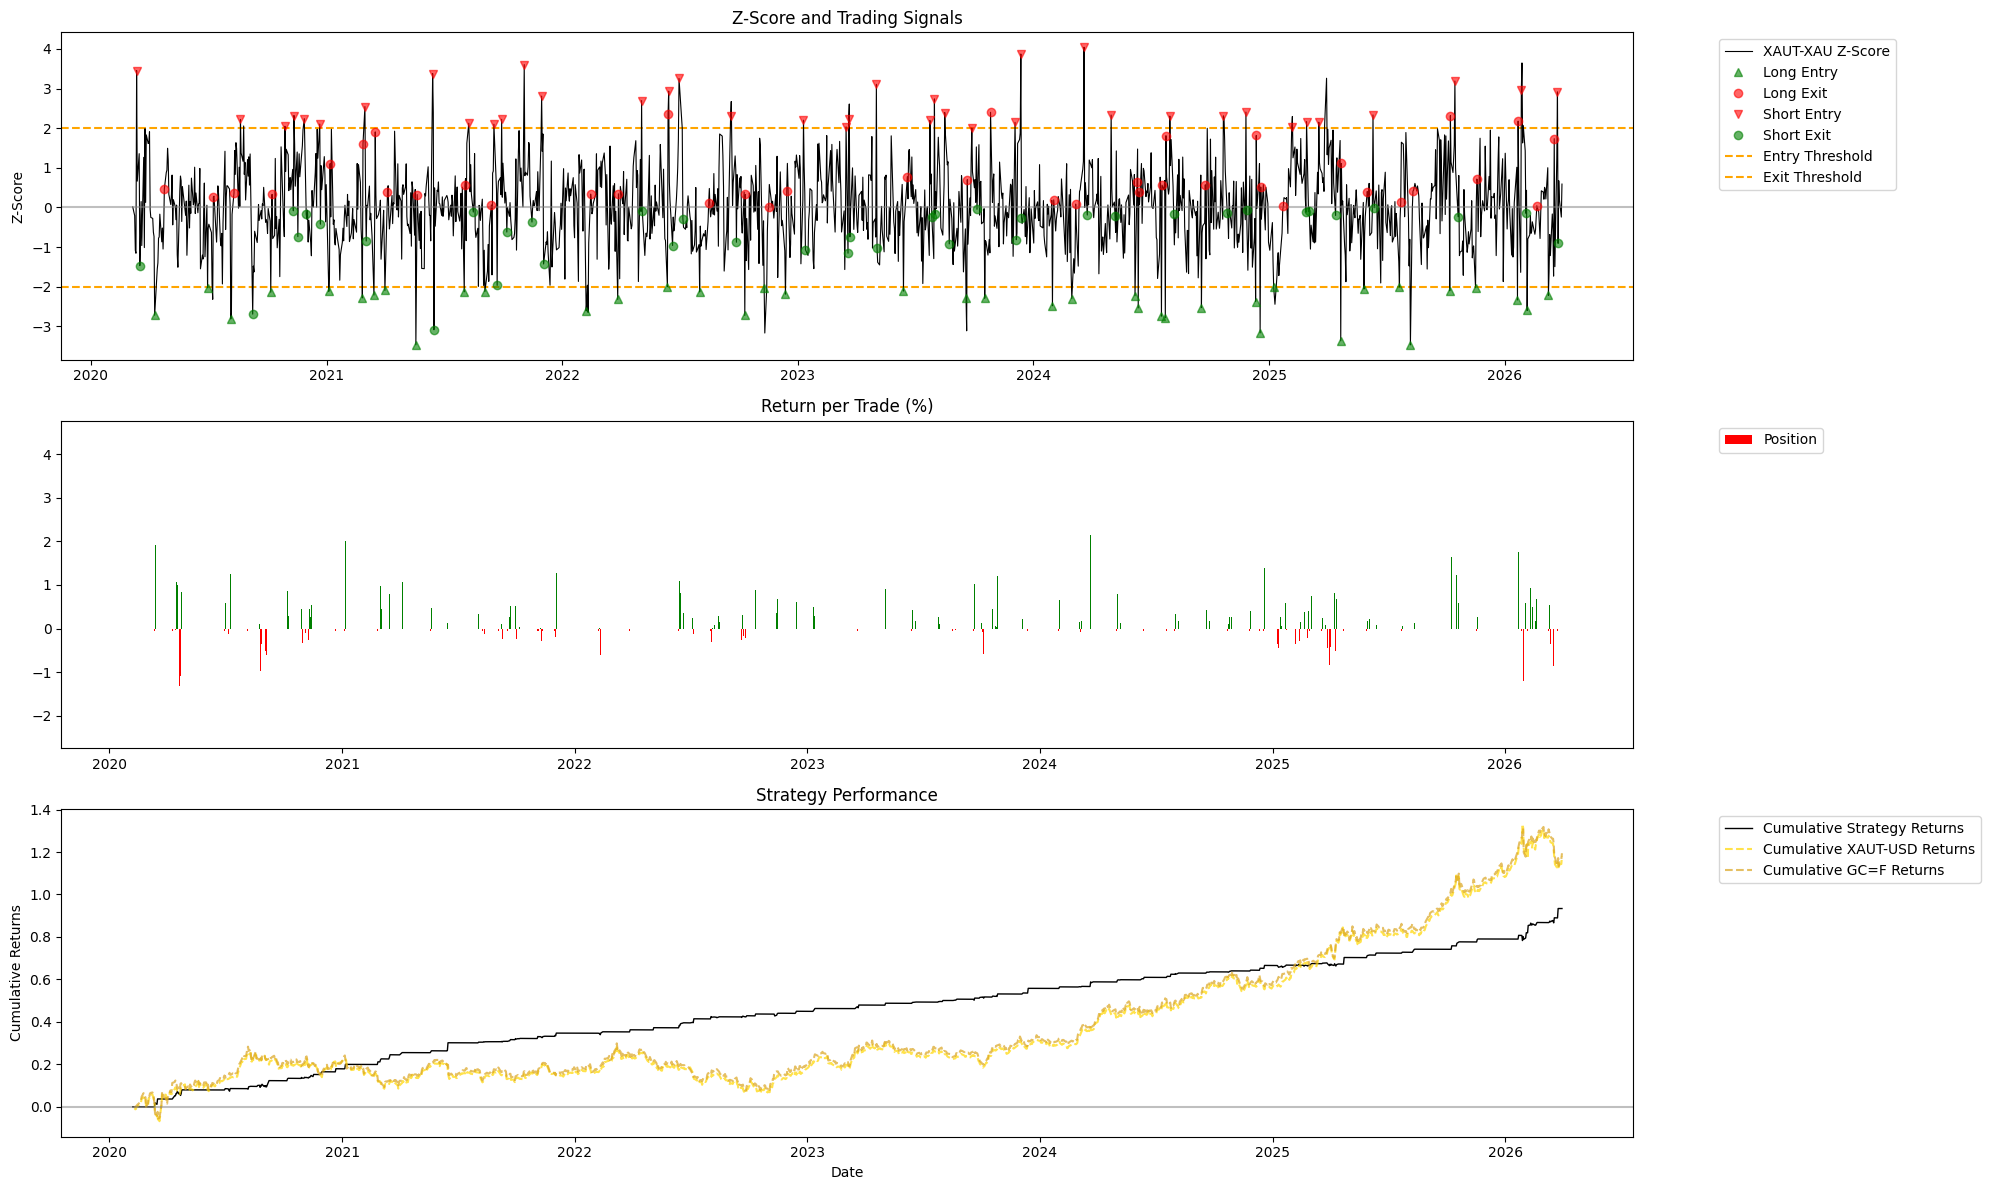

In [ ]:
# Plotting
fig, axs = plt.subplots(3, 1, figsize=(20, 12))

# Define signal markers
entries_long = (df['Position'] == 1) & (df['Position'].shift(1) == 0)
entries_short = (df['Position'] == -1) & (df['Position'].shift(1) == 0)
exits_long = (df['Position'] == 0) & (df['Position'].shift(1) == 1)
exits_short = (df['Position'] == 0) & (df['Position'].shift(1) == -1)

# Plot 1: Z-Score with trading signals
axs[0].plot(df['Z-Score'], label='XAUT-XAU Z-Score', color='black', linewidth=0.8, alpha=1, zorder = 2)
axs[0].plot(df.index, np.where(entries_long, df['Z-Score'], np.nan), label='Long Entry', marker='^', linestyle='', color='green', markersize=6, alpha = 0.6, zorder = 3)
axs[0].plot(df.index, np.where(exits_long, df['Z-Score'], np.nan), label='Long Exit', marker='o', linestyle='', color='red', markersize=6, alpha = 0.6, zorder = 3)
axs[0].plot(df.index, np.where(entries_short, df['Z-Score'], np.nan), label='Short Entry', marker='v', linestyle='', color='red', markersize=6, alpha = 0.6, zorder = 3)
axs[0].plot(df.index, np.where(exits_short, df['Z-Score'], np.nan), label='Short Exit', marker='o', linestyle='', color='green', markersize=6, alpha = 0.6, zorder = 3)
axs[0].axhline(entry_threshold, color='orange', linestyle='--', label='Entry Threshold', zorder = 1)
axs[0].axhline(-entry_threshold, color='orange', linestyle='--', label='Exit Threshold', zorder = 1)
axs[0].axhline(0, color='gray', linestyle='-', alpha=0.5)
axs[0].set_title('Z-Score and Trading Signals')
axs[0].set_ylabel('Z-Score')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Plot 2: Position over time
axs[1].bar(df.index, df['Strategy_Return'] * 100, label='Position', color=np.where(df['Strategy_Return'] > 0, 'green', 'red'), linewidth=2)
axs[1].set_title('Return per Trade (%)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Cumulative returns
axs[2].plot(df['Strategy_Return'].cumsum(), label='Cumulative Strategy Returns', color='black', linewidth=1, alpha=1)
axs[2].plot(df['Asset_A_Return'].cumsum(), label=f'Cumulative {asset_A} Returns', color='gold', linestyle='--', alpha=0.7)
axs[2].plot(df['Asset_B_Return'].cumsum(), label=f'Cumulative {asset_B} Returns', color='goldenrod', linestyle='--', alpha=0.7)
axs[2].set_title('Strategy Performance')
axs[2].set_ylabel('Cumulative Returns')
axs[2].set_xlabel('Date')
axs[2].axhline(0, color='gray', linestyle='-', alpha=0.5)
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

C:\Users\ayode\AppData\Local\Temp\ipykernel_28264\319240428.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(loc='upper left')


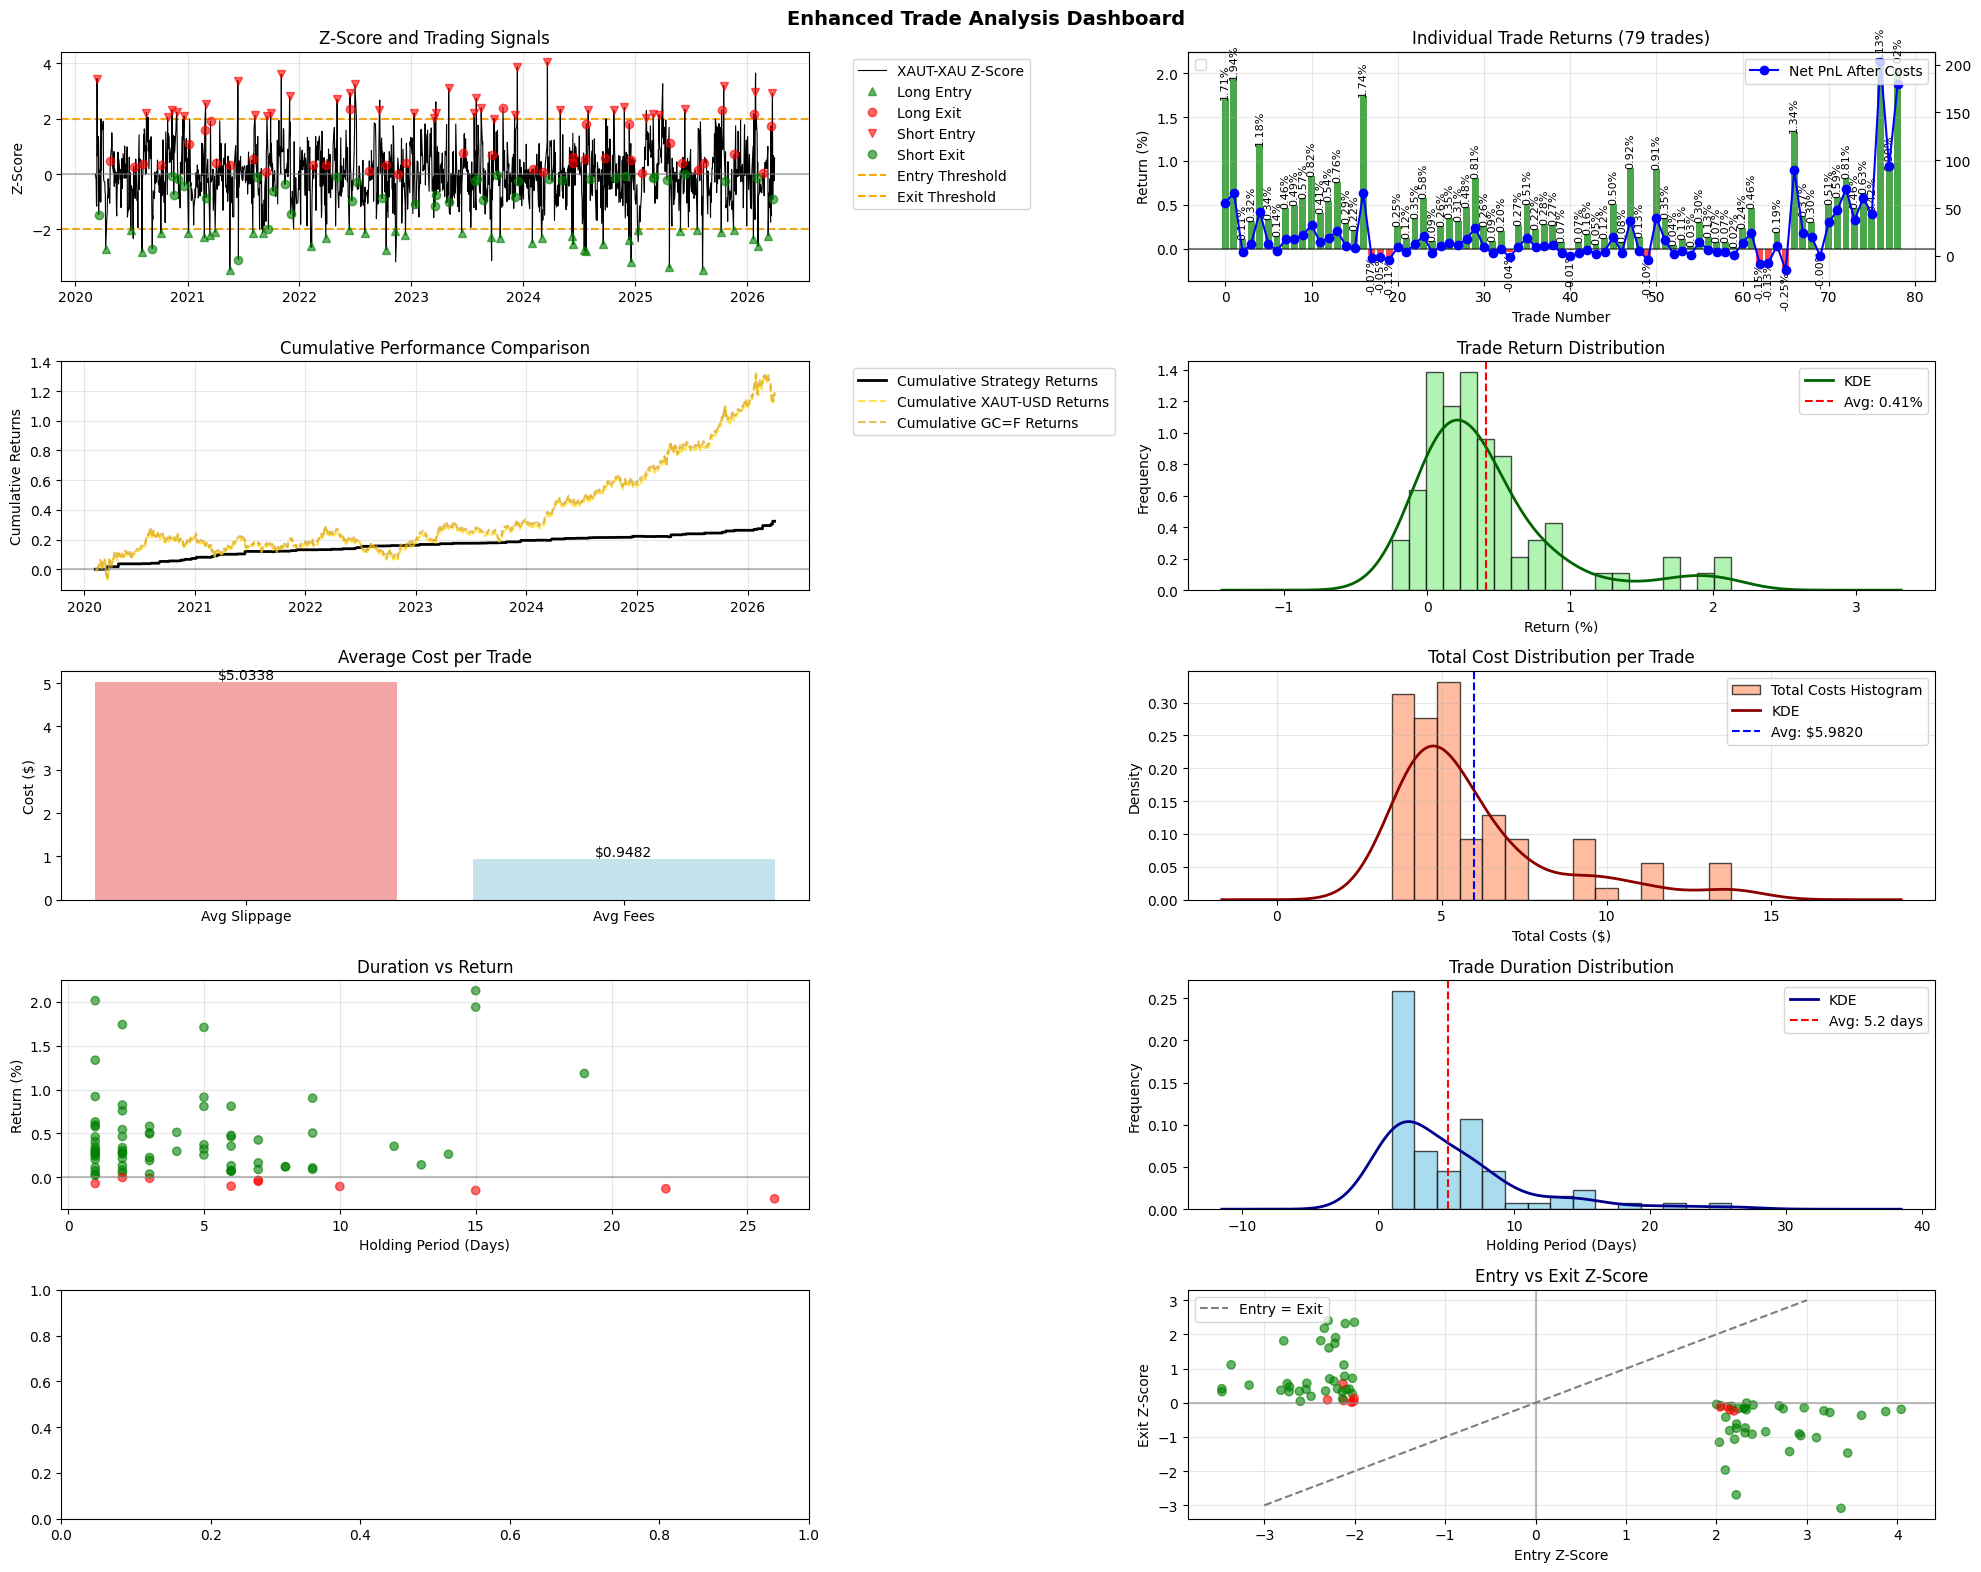

In [ ]:
# Enhanced Plotting with Trade Analysis
fig, axs = plt.subplots(5, 2, figsize=(20, 16))

# Define signal markers
entries_long = (df['Position'] == 1) & (df['Position'].shift(1) == 0)
entries_short = (df['Position'] == -1) & (df['Position'].shift(1) == 0)
exits_long = (df['Position'] == 0) & (df['Position'].shift(1) == 1)
exits_short = (df['Position'] == 0) & (df['Position'].shift(1) == -1)

# Plot 1: Z-Score with trading signals
axs[0,0].plot(df['Z-Score'], label='XAUT-XAU Z-Score', color='black', linewidth=0.8, alpha=1, zorder=2)
axs[0,0].plot(df.index, np.where(entries_long, df['Z-Score'], np.nan), label='Long Entry', marker='^', linestyle='', color='green', markersize=6, alpha=0.6, zorder=3)
axs[0,0].plot(df.index, np.where(exits_long, df['Z-Score'], np.nan), label='Long Exit', marker='o', linestyle='', color='red', markersize=6, alpha=0.6, zorder=3)
axs[0,0].plot(df.index, np.where(entries_short, df['Z-Score'], np.nan), label='Short Entry', marker='v', linestyle='', color='red', markersize=6, alpha=0.6, zorder=3)
axs[0,0].plot(df.index, np.where(exits_short, df['Z-Score'], np.nan), label='Short Exit', marker='o', linestyle='', color='green', markersize=6, alpha=0.6, zorder=3)
axs[0,0].axhline(entry_threshold, color='orange', linestyle='--', label='Entry Threshold', zorder=1)
axs[0,0].axhline(-entry_threshold, color='orange', linestyle='--', label='Exit Threshold', zorder=1)
axs[0,0].axhline(0, color='gray', linestyle='-', alpha=0.5)
axs[0,0].set_title('Z-Score and Trading Signals')
axs[0,0].set_ylabel('Z-Score')
axs[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0,0].grid(True, alpha=0.3)

# Plot 2: Individual trade returns
if len(trades_df) > 0:
    colors = ['green' if x > 0 else 'red' for x in trades_df['return_pct']]
    bars = axs[0,1].bar(range(len(trades_df)), trades_df['return_pct'], color=colors, alpha=0.7)
    axs[0,1].axhline(0, color='black', linestyle='-', alpha=0.5)
    axs[0,1].set_title(f'Individual Trade Returns ({len(trades_df)} trades)')
    axs[0,1].set_ylabel('Return (%)')
    axs[0,1].set_xlabel('Trade Number')

    dollar_ax = axs[0,1].twinx()
    dollar_ax.plot(trades_df['net_pnl_after_costs'], color='blue', marker='o', linestyle='-', label='Net PnL After Costs')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axs[0,1].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top', fontsize=8, rotation=90)
        
axs[0,1].legend(loc='upper left')
dollar_ax.legend(loc='upper right')
axs[0,1].grid(True, alpha=0.3)

# Plot 3: Cumulative strategy performance
axs[1,0].plot(df['Cumulative_Strategy_Return'], label='Cumulative Strategy Returns', color='black', linewidth=2, alpha=1)
axs[1,0].plot(df['Cumulative_Asset_A'], label=f'Cumulative {asset_A} Returns', color='gold', linestyle='--', alpha=0.7)
axs[1,0].plot(df['Cumulative_Asset_B'], label=f'Cumulative {asset_B} Returns', color='goldenrod', linestyle='--', alpha=0.7)
axs[1,0].set_title('Cumulative Performance Comparison')
axs[1,0].set_ylabel('Cumulative Returns')
axs[1,0].axhline(0, color='gray', linestyle='-', alpha=0.5)
axs[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1,0].grid(True, alpha=0.3)

# Plot 4: Trade Returns distribution
if len(trades_df) > 0:
    axs[1,1].hist(trades_df['return_pct'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black', density=True)
    trades_df['return_pct'].plot(kind='kde', ax=axs[1,1], color='darkgreen', linewidth=2, label='KDE')
    axs[1,1].axvline(trades_df['return_pct'].mean(), color='red', linestyle='--', label=f'Avg: {trades_df["return_pct"].mean():.2f}%')
    axs[1,1].set_title('Trade Return Distribution')
    axs[1,1].set_xlabel('Return (%)')
    axs[1,1].set_ylabel('Frequency')
    axs[1,1].legend()
    
    # Native gold return distribution for reference
    # gold_returns = df[asset_B].pct_change().dropna()
    # gold_returns.plot(kind='kde', ax=axs[2,1], color='gold', linestyle='--', linewidth=2, label=f'{asset_B} Return KDE')
    # axs[2,1].hist(gold_returns, bins=20, color='gold', alpha=0.3, edgecolor='black', density=True)
    # axs[2,1].legend()


# Plot 5: Cost breakdown
if len(trades_df) > 0:
    cost_data = [trades_df['total_slippage'].mean(), trades_df['total_fees'].mean()]
    cost_labels = ['Avg Slippage', 'Avg Fees']
    colors = ['lightcoral', 'lightblue']
    
    axs[2,0].bar(cost_labels, cost_data, color=colors, alpha=0.7)
    axs[2,0].set_title('Average Cost per Trade')
    axs[2,0].set_ylabel('Cost ($)')
    
    # Add value labels
    for i, v in enumerate(cost_data):
        axs[2,0].text(i, v, f'${v:.4f}', ha='center', va='bottom')

# Average Cost Distribution
if len(trades_df) > 0:
    axs[2,1].hist(
        trades_df['total_costs'],
        bins=15,
        color='lightsalmon',
        alpha=0.7,
        edgecolor='black',
        density=True,
        label='Total Costs Histogram'
    )
    trades_df['total_costs'].plot(
        kind='kde',
        ax=axs[2,1],
        color='darkred',
        linewidth=2,
        label='KDE'
    )
    avg_cost = trades_df['total_costs'].mean()
    axs[2,1].axvline(
        avg_cost,
        color='blue',
        linestyle='--',
        linewidth=1.5,
        label=f'Avg: ${avg_cost:.4f}'
    )
    axs[2,1].set_title('Total Cost Distribution per Trade')
    axs[2,1].set_xlabel('Total Costs ($)')
    axs[2,1].set_ylabel('Density')
    axs[2,1].legend()
    axs[2,1].grid(True, alpha=0.3)

# Plot 6: Trade Duration Distribution
if len(trades_df) > 0:
    axs[3,1].hist(trades_df['holding_period'], bins=15, color='skyblue', alpha=0.7, edgecolor='black', density=True)
    trades_df['holding_period'].plot(kind='kde', ax=axs[3,1], color='darkblue', linewidth=2, label='KDE')
    axs[3,1].axvline(trades_df['holding_period'].mean(), color='red', linestyle='--', label=f'Avg: {trades_df["holding_period"].mean():.1f} days')
    axs[3,1].set_title('Trade Duration Distribution')
    axs[3,1].set_xlabel('Holding Period (Days)')
    axs[3,1].set_ylabel('Frequency')
    axs[3,1].legend()

# Plot 7: Duration vs Return
if len(trades_df) > 0:
    colors = ['green' if x > 0 else 'red' for x in trades_df['return_pct']]
    axs[3,0].scatter(trades_df['holding_period'], trades_df['return_pct'], c=colors, alpha=0.6)
    axs[3,0].axhline(0, color='gray', linestyle='-', alpha=0.5)
    axs[3,0].set_xlabel('Holding Period (Days)')
    axs[3,0].set_ylabel('Return (%)')
    axs[3,0].set_title('Duration vs Return')
    axs[3,0].grid(True, alpha=0.3)

# Plot 8: Entry vs Exit Z-Score
if len(trades_df) > 0:
    colors = ['green' if x > 0 else 'red' for x in trades_df['net_pnl_after_costs']]
    axs[4,1].scatter(trades_df['entry_zscore'], trades_df['exit_zscore'], c=colors, alpha=0.6)
    axs[4,1].plot([-3, 3], [-3, 3], 'k--', alpha=0.5, label='Entry = Exit')
    axs[4,1].axhline(0, color='gray', linestyle='-', alpha=0.5)
    axs[4,1].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axs[4,1].set_xlabel('Entry Z-Score')
    axs[4,1].set_ylabel('Exit Z-Score')
    axs[4,1].set_title('Entry vs Exit Z-Score')
    axs[4,1].legend()
    axs[4,1].grid(True, alpha=0.3)

plt.suptitle('Enhanced Trade Analysis Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# naive sharpe vs strategy sharpe

sharpe_strategy = df['Strategy_Return'].mean() / df['Strategy_Return'].std() * np.sqrt(252)  # Annualized Sharpe
sharpe_asset_a = df['Asset_A_Return'].mean() / df['Asset_A_Return'].std() * np.sqrt(252)  # Annualized Sharpe
sharpe_asset_b = df['Asset_B_Return'].mean() / df['Asset_B_Return'].std() * np.sqrt(252)  # Annualized Sharpe

print(f"Strategy Sharpe Ratio: {sharpe_strategy:.4f}")
print(f"{asset_A} Sharpe Ratio: {sharpe_asset_a:.4f}")
print(f"{asset_B} Sharpe Ratio: {sharpe_asset_b:.4f}")

Strategy Sharpe Ratio: 2.6804
XAUT-USD Sharpe Ratio: 1.0779
GC=F Sharpe Ratio: 1.0426


In [ ]:
# Enhanced Performance Metrics

if len(trades_df) > 0:
    # Strategy performance metrics
    strategy_returns = df['Strategy_Daily_Return'].dropna()
    sharpe_strategy = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252) if strategy_returns.std() > 0 else 0
    
    # Asset performance metrics for comparison
    asset_a_returns = df['Asset_A_Return'].dropna()
    asset_b_returns = df['Asset_B_Return'].dropna()
    sharpe_asset_a = asset_a_returns.mean() / asset_a_returns.std() * np.sqrt(252) if asset_a_returns.std() > 0 else 0
    sharpe_asset_b = asset_b_returns.mean() / asset_b_returns.std() * np.sqrt(252) if asset_b_returns.std() > 0 else 0
    
    # Trade-based metrics
    total_return = trades_df['net_pnl_after_costs'].sum()
    avg_return_per_trade = trades_df['return_pct'].mean()
    win_rate = (trades_df['net_pnl_after_costs'] > 0).mean() * 100
    
    # Risk metrics
    max_loss = trades_df['return_pct'].min()
    max_gain = trades_df['return_pct'].max()
    
    # Average costs
    avg_slippage = trades_df['total_slippage'].mean()
    avg_fees = trades_df['total_fees'].mean()
    avg_total_costs = trades_df['total_costs'].mean()
    
    # Print comprehensive results
    print("=" * 60)
    print("STRATEGY PERFORMANCE SUMMARY")
    print("=" * 60)
    print(f"Strategy Sharpe Ratio: {sharpe_strategy:.4f}")
    print(f"{asset_A} Sharpe Ratio: {sharpe_asset_a:.4f}")
    print(f"{asset_B} Sharpe Ratio: {sharpe_asset_b:.4f}")
    print()
    print("TRADE STATISTICS:")
    print(f"Total Trades: {len(trades_df)}")
    print(f"Winning Trades: {(trades_df['net_pnl_after_costs'] > 0).sum()}")
    print(f"Losing Trades: {(trades_df['net_pnl_after_costs'] < 0).sum()}")
    print(f"Win Rate: {win_rate:.1f}%")
    print(f"Average Return per Trade: {avg_return_per_trade:.4f}%")
    print(f"Best Trade: {max_gain:.4f}%")
    print(f"Worst Trade: {max_loss:.4f}%")
    print(f"Total Strategy Return: {strategy_returns.sum() * 100:.4f}%")
    print()
    print("TRADE COSTS:")
    print(f"Average Slippage per Trade: ${avg_slippage:.4f}")
    print(f"Average Fees per Trade: ${avg_fees:.4f}")
    print(f"Average Total Costs per Trade: ${avg_total_costs:.4f}")
    print(f"Total Costs as % of PnL: {(trades_df['total_costs'].sum() / abs(trades_df['net_pnl'].sum()) * 100):.2f}%")
    print()
    print("TRADE DURATION:")
    print(f"Average Holding Period: {trades_df['holding_period'].mean():.1f} days")
    print(f"Min Holding Period: {trades_df['holding_period'].min():.0f} days")
    print(f"Max Holding Period: {trades_df['holding_period'].max():.0f} days")
    
else:
    print("No trades were executed during the backtest period.")
    print("Consider adjusting entry/exit thresholds or checking data quality.")

STRATEGY PERFORMANCE SUMMARY
Strategy Sharpe Ratio: -2.3863
XAUT-USD Sharpe Ratio: 1.0779
GC=F Sharpe Ratio: 1.0426

TRADE STATISTICS:
Total Trades: 79
Winning Trades: 1
Losing Trades: 78
Win Rate: 1.3%
Average Return per Trade: -3.6646%
Best Trade: 0.5741%
Worst Trade: -28.7016%
Total Strategy Return: -289.5030%

TRADE COSTS:
Average Slippage per Trade: $3997.5519
Average Fees per Trade: $151.4828
Average Total Costs per Trade: $151.4828
Total Costs as % of PnL: 5.03%

TRADE DURATION:
Average Holding Period: 5.2 days
Min Holding Period: 1 days
Max Holding Period: 26 days


In [ ]:
# Display detailed trades table
if len(trades_df) > 0:
    print("\nDETAILED TRADES TABLE:")
    print("=" * 100)
    
    # Create a formatted display DataFrame
    display_df = trades_df.copy()
    
    # Format columns for better readability
    display_df['entry_date'] = display_df['entry_date'].dt.strftime('%Y-%m-%d')
    display_df['exit_date'] = display_df['exit_date'].dt.strftime('%Y-%m-%d')
    
    # Select key columns for display
    key_columns = [
        'entry_date', 'exit_date', 'direction', 'holding_period', 'entry_price_a', 'exit_price_a', 'entry_price_b', 'exit_price_b',
        'entry_zscore', 'exit_zscore', 'return_pct', 'net_pnl_after_costs',
        'total_costs', 'pnl_a', 'pnl_b'
    ]
    
    # Round numeric columns
    numeric_columns = ['entry_zscore', 'exit_zscore', 'return_pct', 'net_pnl_after_costs', 
                      'total_costs', 'pnl_a', 'pnl_b', 'entry_price_a', 'exit_price_a', 'entry_price_b', 'exit_price_b']
    for col in numeric_columns:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    # Display first 10 trades with key metrics
    if len(display_df) > 10:
        print("(Showing first 10 trades)")
        print(display_df[key_columns].head(10).to_string(index=False))
        print(f"\n... and {len(display_df) - 10} more trades")
    else:
        print(display_df[key_columns].to_string(index=False))
        
    # Save trades to CSV for detailed analysis
    csv_path = "detailed_trades_analysis.csv"
    trades_df.to_csv(csv_path, index=False)
    print(f"\nDetailed trades saved to: {csv_path}")
else:
    print("No trades data available to display.")


DETAILED TRADES TABLE:
(Showing first 10 trades)
entry_date  exit_date direction  holding_period  entry_price_a  exit_price_a  entry_price_b  exit_price_b  entry_zscore  exit_zscore  return_pct  net_pnl_after_costs  total_costs      pnl_a      pnl_b
2020-03-12 2020-03-17     short               5      1621.3040     1595.7768      1599.9164     1500.0863        3.4522      -1.4702     -4.7665           -2334.6006     105.5124   765.8136 -2994.9018
2020-04-09 2020-04-24      long              15      1688.1794     1694.7336      1673.5435     1784.0936       -2.7221       0.4662     -6.4392           -3230.3666     110.4874   196.6246 -3316.5038
2020-06-30 2020-07-09      long               9      1777.7632     1790.1029      1780.2849     1822.4606       -2.0278       0.2642     -1.8970           -1011.1167     116.0360   370.1903 -1265.2710
2020-08-05 2020-08-10      long               5      2014.9051     2012.7757      2013.5785     2035.1475       -2.8172       0.3665     -1.4032  

In [ ]:
assess long short strategy
compare to native gold

SyntaxError: invalid syntax (3774891868.py, line 1)

In [ ]:
use machine learning models to predict spread movements and generate trading signals, and find when long short strategy works best, and when it doesn't work, and try to find patterns in those times, and see if we can use that to improve the strategy, and also try to find patterns in the times when the strategy works best, and see if we can use that to improve the strategy as well, and also try to find patterns in the times when the strategy doesn't work, and see if we can use that to improve the strategy as well, and also try to find patterns in the times when the strategy works best, and see if we can use that to improve the strategy as well, and also try to find patterns in the times when the strategy doesn't work, and see if we can use that to improve the strategy as well